# Card Pre-Grading Analysis

Estimates a PSA-style grade (1–10) from a card image using computer vision.

## Pipeline
1. **Card detection** — find the card in the photo (OpenCV contours or YOLOv8)
2. **Deskew** — perspective-correct to a flat, upright card
3. **Centering** — measure border ratios on all four sides
4. **Corners** — detect rounding / fraying at each corner
5. **Edges** — detect chips, roughness, whitening along each edge
6. **Surface** — detect scratches, print lines, stains
7. **Grade** — weight sub-scores into a PSA 1–10 estimate

## Grade weights (mirrors PSA emphasis)
| Dimension  | Weight |
|------------|--------|
| Corners    | 35%    |
| Centering  | 25%    |
| Edges      | 25%    |
| Surface    | 15%    |

## 0. Install Dependencies

In [1]:
# Run once — comment out after first install
import subprocess, sys

packages = [
    'ultralytics',      # YOLOv8
    'opencv-python',
    'numpy',
    'Pillow',
    'matplotlib',
    'scipy',
    'scikit-image',
    'ipywidgets',
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + packages)
print('✅ Dependencies installed')

✅ Dependencies installed


## 1. Imports & Config

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from PIL import Image
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Tuple, List
import warnings
warnings.filterwarnings('ignore')

# ── Display config ────────────────────────────────────────────────
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.facecolor'] = '#0d1117'
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

# ── Grading weights ───────────────────────────────────────────────
WEIGHTS = {
    'corners':   0.35,
    'centering': 0.25,
    'edges':     0.25,
    'surface':   0.15,
}

# Standard trading card dimensions (mm) — used only for aspect ratio check
CARD_ASPECT_RATIO = 88.0 / 63.0   # height / width ≈ 1.397
ASPECT_TOLERANCE  = 0.15           # allow ±15%

print('✅ Imports ready')

✅ Imports ready


## 2. Data Classes

In [3]:
@dataclass
class CenteringResult:
    left_pct:   float   # left border as % of total width
    right_pct:  float
    top_pct:    float
    bottom_pct: float
    h_ratio:    float   # left/right (>1 = shifted right)
    v_ratio:    float   # top/bottom (>1 = shifted down)
    score:      float   # 0–100
    grade:      str


@dataclass
class CornerResult:
    scores:    List[float]   # TL, TR, BL, BR — each 0–100
    mean:      float
    worst:     float
    images:    List[np.ndarray] = field(default_factory=list)


@dataclass
class EdgeResult:
    scores:    List[float]   # top, right, bottom, left — each 0–100
    mean:      float
    worst:     float


@dataclass
class SurfaceResult:
    scratch_density: float   # 0–1
    gloss_variance:  float   # lower = more uniform surface
    defect_count:    int
    score:           float   # 0–100


@dataclass
class GradeReport:
    image_path:  str
    centering:   CenteringResult
    corners:     CornerResult
    edges:       EdgeResult
    surface:     SurfaceResult
    sub_scores:  dict        # per-dimension 0–100
    composite:   float       # weighted 0–100
    psa_estimate: float      # 1–10
    psa_label:   str         # e.g. "PSA 9 (Mint)"
    confidence:  str         # Low / Medium / High

print('✅ Data classes ready')

✅ Data classes ready


## 3. Card Detection & Deskew

Two strategies are tried in order:
1. **YOLOv8 segmentation** — most robust, handles busy backgrounds
2. **OpenCV contour fallback** — works well on plain/white backgrounds

In [4]:
def order_points(pts: np.ndarray) -> np.ndarray:
    """Order 4 points as [TL, TR, BR, BL]."""
    rect = np.zeros((4, 2), dtype='float32')
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # TL — smallest sum
    rect[2] = pts[np.argmax(s)]   # BR — largest sum
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)] # TR — smallest diff
    rect[3] = pts[np.argmax(diff)] # BL — largest diff
    return rect


def four_point_transform(image: np.ndarray, pts: np.ndarray) -> np.ndarray:
    """Perspective-warp image to a flat rectangle using 4 corner points."""
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    width_a  = np.linalg.norm(br - bl)
    width_b  = np.linalg.norm(tr - tl)
    max_w    = int(max(width_a, width_b))

    height_a = np.linalg.norm(tr - br)
    height_b = np.linalg.norm(tl - bl)
    max_h    = int(max(height_a, height_b))

    dst = np.array([
        [0, 0], [max_w - 1, 0],
        [max_w - 1, max_h - 1], [0, max_h - 1],
    ], dtype='float32')

    M    = cv2.getPerspectiveTransform(rect, dst)
    warp = cv2.warpPerspective(image, M, (max_w, max_h))
    return warp


def detect_card_contour(image: np.ndarray) -> Optional[np.ndarray]:
    """
    Find the card using edge detection + contour analysis.
    Returns 4-point numpy array (corners) or None.
    """
    h, w = image.shape[:2]
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # ── Preprocessing ────────────────────────────────────────────
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    # Adaptive threshold handles varying lighting
    thresh  = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 21, 10
    )
    # Also try Canny for cleaner edges
    edges   = cv2.Canny(blurred, 30, 120)
    combined = cv2.bitwise_or(thresh, edges)
    dilated  = cv2.dilate(combined, np.ones((3, 3), np.uint8), iterations=2)

    # ── Contour finding ───────────────────────────────────────────
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

    min_area = (w * h) * 0.05   # card must be at least 5% of image

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue

        peri   = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

        if len(approx) == 4:
            pts = approx.reshape(4, 2).astype('float32')
            # Check aspect ratio
            rect    = order_points(pts)
            card_w  = np.linalg.norm(rect[1] - rect[0])
            card_h  = np.linalg.norm(rect[3] - rect[0])
            if card_w < 1:
                continue
            ratio = card_h / card_w
            # Accept portrait or landscape orientation
            if (abs(ratio - CARD_ASPECT_RATIO) < ASPECT_TOLERANCE or
                abs(ratio - 1/CARD_ASPECT_RATIO) < ASPECT_TOLERANCE):
                return pts

    return None


def detect_card_yolo(image: np.ndarray, model) -> Optional[np.ndarray]:
    """
    Use YOLOv8 segmentation to find the card.
    Falls back to bounding-box corners if no mask is returned.
    """
    results = model(image, verbose=False)
    if not results or results[0].masks is None:
        # Try bounding boxes
        if results and len(results[0].boxes) > 0:
            box = results[0].boxes[0].xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = box
            return np.array([[x1,y1],[x2,y1],[x2,y2],[x1,y2]], dtype='float32')
        return None

    # Use largest mask
    masks = results[0].masks.xy
    if not masks:
        return None
    mask_pts = max(masks, key=lambda m: cv2.contourArea(m.astype(np.float32)))
    hull     = cv2.convexHull(mask_pts.astype(np.float32))
    peri     = cv2.arcLength(hull, True)
    approx   = cv2.approxPolyDP(hull, 0.02 * peri, True)
    if len(approx) == 4:
        return approx.reshape(4, 2).astype('float32')
    # Fit bounding rect of mask
    rect = cv2.minAreaRect(mask_pts.astype(np.float32))
    return cv2.boxPoints(rect).astype('float32')


def extract_card(
    image_path: str,
    yolo_model=None,
    target_h: int = 1000,
) -> Tuple[np.ndarray, np.ndarray, str]:
    """
    Load image, detect card, return (original_bgr, warped_bgr, method).
    If detection fails, crops to center 80% of image.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f'Cannot load image: {image_path}')

    # Downscale for speed while keeping detection quality
    h, w = img.shape[:2]
    scale = min(1.0, 1200 / max(h, w))
    small = cv2.resize(img, (int(w*scale), int(h*scale)))

    corners = None
    method  = 'unknown'

    # 1. Try YOLOv8
    if yolo_model is not None:
        corners = detect_card_yolo(small, yolo_model)
        if corners is not None:
            corners = corners / scale   # scale back to full res
            method  = 'yolo'

    # 2. Fallback: contour
    if corners is None:
        corners = detect_card_contour(small)
        if corners is not None:
            corners = corners / scale
            method  = 'contour'

    # 3. Last resort: center crop
    if corners is None:
        pad_h, pad_w = int(h * 0.1), int(w * 0.1)
        warped = img[pad_h:h-pad_h, pad_w:w-pad_w]
        method = 'center_crop'
    else:
        warped = four_point_transform(img, corners)

    # Ensure portrait orientation
    wh, ww = warped.shape[:2]
    if ww > wh:
        warped = cv2.rotate(warped, cv2.ROTATE_90_CLOCKWISE)

    # Resize to standard height
    wh, ww = warped.shape[:2]
    new_w   = int(target_h * ww / wh)
    warped  = cv2.resize(warped, (new_w, target_h))

    return img, warped, method


print('✅ Card detection helpers ready')

✅ Card detection helpers ready


## 4. Centering Analysis

In [5]:
def analyze_centering(card: np.ndarray, border_frac: float = 0.08) -> CenteringResult:
    """
    Measure the inner artwork border by scanning inward from each edge
    until hitting the artwork area.

    Strategy:
      - Convert to LAB color space
      - The card border is typically a uniform color (white, yellow, black)
      - Scan from each edge inward; detect first significant color change
    """
    h, w = card.shape[:2]
    lab   = cv2.cvtColor(card, cv2.COLOR_BGR2LAB)

    def find_border_width(strip: np.ndarray, from_start=True) -> int:
        """Scan 1D strip, return width of uniform region at one end."""
        n = len(strip)
        if n < 4:
            return 0
        ref = strip[0] if from_start else strip[-1]
        direction = range(n) if from_start else range(n-1, -1, -1)
        for i in direction:
            diff = float(np.linalg.norm(strip[i].astype(float) - ref.astype(float)))
            if diff > 18:   # color threshold
                return abs(i - (0 if from_start else n-1))
        return n // 4   # fallback: assume 25% border

    # Sample multiple column/row strips and take the median
    n_samples = 10

    # Left / right borders: scan horizontally along the card midpoint area
    row_samples = np.linspace(h * 0.3, h * 0.7, n_samples, dtype=int)
    left_widths  = [find_border_width(lab[r, :w//2, :], from_start=True)  for r in row_samples]
    right_widths = [find_border_width(lab[r, w//2:, :], from_start=False) for r in row_samples]
    left_w  = int(np.median(left_widths))
    right_w = int(np.median(right_widths))

    # Top / bottom borders
    col_samples = np.linspace(w * 0.3, w * 0.7, n_samples, dtype=int)
    top_widths    = [find_border_width(lab[:h//2, c, :], from_start=True)  for c in col_samples]
    bottom_widths = [find_border_width(lab[h//2:, c, :], from_start=False) for c in col_samples]
    top_h    = int(np.median(top_widths))
    bottom_h = int(np.median(bottom_widths))

    # Convert to percentages
    total_w = max(left_w + right_w, 1)
    total_h = max(top_h + bottom_h, 1)
    left_pct   = left_w   / total_w
    right_pct  = right_w  / total_w
    top_pct    = top_h    / total_h
    bottom_pct = bottom_h / total_h

    h_ratio = left_pct / right_pct  if right_pct > 0 else 1.0
    v_ratio = top_pct  / bottom_pct if bottom_pct > 0 else 1.0

    # Score: PSA centering standards
    # PSA 10: 55/45 front, 75/25 back
    # PSA 9:  60/40
    # PSA 8:  65/35
    def centering_score(ratio: float) -> float:
        """ratio = larger/smaller side (always >= 1). Returns 0-100."""
        r = max(ratio, 1/ratio)   # normalize to >= 1
        if r <= 1.10: return 100.0   # 55/45 — gem mint
        if r <= 1.22: return  90.0   # 55/45 — mint 9
        if r <= 1.40: return  80.0   # 58/42 — NM-MT 8
        if r <= 1.60: return  65.0   # 60/40
        if r <= 2.00: return  50.0   # 67/33
        if r <= 2.50: return  35.0   # 71/29
        if r <= 3.00: return  20.0
        return 10.0

    h_score = centering_score(h_ratio)
    v_score = centering_score(v_ratio)
    score   = (h_score + v_score) / 2

    # PSA grade label for centering
    r = max(max(h_ratio, 1/h_ratio), max(v_ratio, 1/v_ratio))
    grade = ('55/45' if r <= 1.22 else
             '60/40' if r <= 1.50 else
             '65/35' if r <= 1.86 else
             '70/30' if r <= 2.33 else '75/25+')

    return CenteringResult(
        left_pct=left_pct, right_pct=right_pct,
        top_pct=top_pct,   bottom_pct=bottom_pct,
        h_ratio=h_ratio,   v_ratio=v_ratio,
        score=score,       grade=grade,
    )

print('✅ Centering analyzer ready')

✅ Centering analyzer ready


## 5. Corner Analysis

In [6]:
def analyze_corners(card: np.ndarray, corner_pct: float = 0.10) -> CornerResult:
    """
    Assess each corner for sharpness vs rounding/fraying.

    Metrics per corner:
      - Edge sharpness: Laplacian variance (high = sharp)
      - Corner acuteness: angle of the corner point detected by Harris
      - Fraying: high-frequency noise in the corner patch
    """
    h, w = card.shape[:2]
    ch   = int(h * corner_pct)
    cw   = int(w * corner_pct)

    # Extract the four corner patches
    corners_patches = [
        card[:ch,    :cw   ],   # TL
        card[:ch,    w-cw: ],   # TR
        card[h-ch:,  :cw   ],   # BL
        card[h-ch:,  w-cw: ],   # BR
    ]
    labels = ['TL', 'TR', 'BL', 'BR']

    scores = []
    corner_images = []

    for i, patch in enumerate(corners_patches):
        gray_p = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)  # uint8

        # ── Sharpness via Laplacian ───────────────────────────────
        lap_var = cv2.Laplacian(gray_p, cv2.CV_32F).var()  # uint8→float32 (CV_64F breaks on float32 src in OpenCV 4.13)
        # A sharp corner has high variance (lots of edge energy)
        # Normalize: 0=no edges (rounded/worn), 100=very sharp
        sharpness = min(100.0, lap_var / 4.0)

        # ── Corner point detection via Harris ─────────────────────
        harris = cv2.cornerHarris(gray_p.astype(np.float32) / 255.0, blockSize=3, ksize=3, k=0.04)
        harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        # Count strong corner responses — a worn corner has fewer
        strong_corners = np.sum(harris_norm > 200) / harris_norm.size
        corner_presence = min(100.0, strong_corners * 5000)

        # ── Fraying: high-freq noise at the very tip ──────────────
        # Detect white/light pixels straying into the corner tip
        # (fraying shows as white fibers against the card border color)
        # Take the innermost 20% of the corner patch
        tip_h = max(4, int(gray_p.shape[0] * 0.20))
        tip_w = max(4, int(gray_p.shape[1] * 0.20))
        # The actual corner tip position depends on which corner
        tips = {
            0: gray_p[-tip_h:, -tip_w:],   # TL → bottom-right of patch
            1: gray_p[-tip_h:,  :tip_w ],   # TR → bottom-left
            2: gray_p[ :tip_h,  -tip_w:],   # BL → top-right
            3: gray_p[ :tip_h,   :tip_w],   # BR → top-left
        }
        tip = tips[i]
        # High std of the tip relative to border color = fraying
        tip_std = tip.std()
        fray_penalty = min(30.0, tip_std * 0.5)

        # ── Composite corner score ────────────────────────────────
        raw = sharpness * 0.5 + corner_presence * 0.4
        score = max(0.0, min(100.0, raw - fray_penalty))
        scores.append(score)

        # Save annotated patch for visualization
        annotated = patch.copy()
        cv2.putText(annotated, f'{labels[i]} {score:.0f}',
                    (2, 12), cv2.FONT_HERSHEY_SIMPLEX, 0.4,
                    (0, 255, 0) if score > 70 else (0, 165, 255) if score > 40 else (0, 0, 255),
                    1, cv2.LINE_AA)
        corner_images.append(annotated)

    return CornerResult(
        scores=scores,
        mean=float(np.mean(scores)),
        worst=float(np.min(scores)),
        images=corner_images,
    )

print('✅ Corner analyzer ready')

✅ Corner analyzer ready


## 6. Edge Analysis

In [7]:
def analyze_edges(card: np.ndarray, edge_pct: float = 0.05) -> EdgeResult:
    """
    Scan each edge strip for:
      - Chipping: localized brightness spikes (white paper showing)
      - Roughness: high variation along the edge
      - Dents: local dark depressions
    """
    h, w = card.shape[:2]
    ep_h = max(4, int(h * edge_pct))
    ep_w = max(4, int(w * edge_pct))

    # Edge strips: top, right, bottom, left
    strips = [
        card[:ep_h,      ep_w:w-ep_w],   # top
        card[ep_h:h-ep_h, w-ep_w:    ],  # right
        card[h-ep_h:,    ep_w:w-ep_w],   # bottom
        card[ep_h:h-ep_h, :ep_w      ],  # left
    ]

    scores = []
    for strip in strips:
        if strip.size == 0:
            scores.append(50.0)
            continue

        gray   = cv2.cvtColor(strip, cv2.COLOR_BGR2GRAY).astype(float)

        # ── Roughness: std along the innermost edge row/col ───────
        # High std = rough, chipped edge
        if strip.shape[0] >= strip.shape[1]:  # tall strip (left/right)
            edge_line = gray[:, 0]   # innermost column
        else:                                  # wide strip (top/bottom)
            edge_line = gray[0, :]   # innermost row

        roughness = edge_line.std()
        roughness_score = max(0.0, 100.0 - roughness * 2.0)

        # ── Chip detection: sudden bright spikes ──────────────────
        # Paper core shows as white when edge chips
        bright_threshold = np.percentile(gray, 85) + 20
        chip_pixels = np.sum(gray > min(bright_threshold, 240))
        chip_density = chip_pixels / gray.size
        chip_penalty = min(40.0, chip_density * 800)

        # ── Straightness: line fit residual ──────────────────────
        # A perfectly straight edge fits a line with low residual
        ys = np.arange(len(edge_line))
        if len(ys) > 2:
            coeffs   = np.polyfit(ys, edge_line, 1)
            residual = np.abs(edge_line - np.polyval(coeffs, ys)).mean()
            straightness = max(0.0, 100.0 - residual * 3.0)
        else:
            straightness = 80.0

        score = roughness_score * 0.45 + straightness * 0.35 - chip_penalty * 0.20
        scores.append(max(0.0, min(100.0, score)))

    return EdgeResult(
        scores=scores,
        mean=float(np.mean(scores)),
        worst=float(np.min(scores)),
    )

print('✅ Edge analyzer ready')

✅ Edge analyzer ready


## 7. Surface Analysis

In [8]:
def analyze_surface(card: np.ndarray, border_pct: float = 0.12) -> SurfaceResult:
    """
    Detect scratches, print lines, and surface defects on the artwork area.

    Approach:
      - Crop to inner artwork (exclude border)
      - Detect linear scratch artifacts via Hough line transform
      - Measure surface gloss uniformity (scratches disrupt gloss)
      - Count blob defects (stains, print spots)
    """
    h, w = card.shape[:2]
    ph   = int(h * border_pct)
    pw   = int(w * border_pct)
    # Crop to artwork area only
    artwork = card[ph:h-ph, pw:w-pw]
    if artwork.size == 0:
        return SurfaceResult(0, 0, 0, 80.0)

    gray = cv2.cvtColor(artwork, cv2.COLOR_BGR2GRAY)

    # ── Scratch detection via Hough lines ─────────────────────────
    # Scratches appear as thin, straight, high-contrast lines
    edges = cv2.Canny(gray, 40, 120)
    lines = cv2.HoughLinesP(
        edges, rho=1, theta=np.pi/180,
        threshold=30, minLineLength=gray.shape[1]//6, maxLineGap=8
    )
    scratch_count = len(lines) if lines is not None else 0
    # Filter out card art lines (very horizontal/vertical in artwork are normal)
    if lines is not None:
        real_scratches = 0
        for line in lines:
            x1, y1, x2, y2 = line[0]
            angle = abs(np.degrees(np.arctan2(y2-y1, x2-x1)))
            # Diagonal lines (15–75°) are more likely scratches
            if 15 < angle < 75:
                real_scratches += 1
        scratch_count = real_scratches
    scratch_density = scratch_count / max(artwork.shape[0] * artwork.shape[1] / 10000, 1)

    # ── Gloss / surface uniformity ────────────────────────────────
    # Convert to HSV; V channel captures brightness uniformity
    hsv      = cv2.cvtColor(artwork, cv2.COLOR_BGR2HSV)
    v_chan   = hsv[:, :, 2].astype(float)
    # Use local standard deviation as a proxy for surface texture variation
    from scipy.ndimage import uniform_filter
    local_mean = uniform_filter(v_chan, size=15)
    local_var  = uniform_filter((v_chan - local_mean) ** 2, size=15)
    gloss_var  = float(np.mean(local_var))

    # ── Blob / stain detection ─────────────────────────────────────
    params = cv2.SimpleBlobDetector_Params()
    params.filterByArea    = True
    params.minArea         = 30
    params.maxArea         = gray.shape[0] * gray.shape[1] * 0.02
    params.filterByColor   = True
    params.blobColor       = 0       # dark blobs (stains, dirt)
    params.filterByCircularity = False
    detector    = cv2.SimpleBlobDetector_create(params)
    keypoints   = detector.detect(gray)
    defect_count = len(keypoints)

    # ── Composite score ───────────────────────────────────────────
    scratch_penalty = min(50.0, scratch_density * 25.0)
    gloss_penalty   = min(20.0, gloss_var / 100.0)
    defect_penalty  = min(30.0, defect_count * 3.0)

    score = max(0.0, 100.0 - scratch_penalty - gloss_penalty - defect_penalty)

    return SurfaceResult(
        scratch_density=scratch_density,
        gloss_variance=gloss_var,
        defect_count=defect_count,
        score=score,
    )

print('✅ Surface analyzer ready')

✅ Surface analyzer ready


## 8. Grade Calculator

In [9]:
PSA_LABELS = {
    10: 'Gem Mint',
     9: 'Mint',
     8: 'Near Mint-Mint',
     7: 'Near Mint',
     6: 'Excellent-Mint',
     5: 'Excellent',
     4: 'Very Good-Excellent',
     3: 'Very Good',
     2: 'Good',
     1: 'Poor',
}

def composite_to_psa(composite: float, worst_corner: float) -> float:
    """
    Map 0-100 composite score to PSA 1-10.

    A single very bad corner can cap the grade (PSA is strict).
    """
    # Base grade from composite
    thresholds = [
        (95, 10.0), (88, 9.5), (82, 9.0),
        (75, 8.0),  (67, 7.0), (58, 6.0),
        (48, 5.0),  (38, 4.0), (28, 3.0),
        (18, 2.0),  (0,  1.0),
    ]
    grade = 1.0
    for threshold, g in thresholds:
        if composite >= threshold:
            grade = g
            break

    # Worst-corner cap: one ruined corner limits the overall grade
    # (mirrors PSA practice — one bad corner = can't be a 9)
    corner_cap = (
        10.0 if worst_corner > 85 else
         9.0 if worst_corner > 70 else
         8.0 if worst_corner > 55 else
         6.0 if worst_corner > 40 else
         4.0 if worst_corner > 25 else 2.0
    )
    grade = min(grade, corner_cap)

    # Snap to nearest integer grade (PSA doesn't give half-grades except 1.5)
    return round(max(1.0, min(10.0, grade)))


def grade_card(
    image_path: str,
    yolo_model=None,
) -> GradeReport:
    """
    Full pipeline: detect → deskew → analyze → grade.
    """
    _, card, method = extract_card(image_path, yolo_model)

    centering = analyze_centering(card)
    corners   = analyze_corners(card)
    edges     = analyze_edges(card)
    surface   = analyze_surface(card)

    # Corner score: blend mean and worst (worst matters more)
    corner_score = corners.mean * 0.4 + corners.worst * 0.6
    edge_score   = edges.mean   * 0.5 + edges.worst   * 0.5

    sub_scores = {
        'corners':   corner_score,
        'centering': centering.score,
        'edges':     edge_score,
        'surface':   surface.score,
    }

    composite = sum(sub_scores[k] * WEIGHTS[k] for k in WEIGHTS)
    psa_est   = composite_to_psa(composite, corners.worst)
    psa_int   = int(psa_est)
    psa_label = f'PSA {psa_int} ({PSA_LABELS[psa_int]})'

    # Confidence: low if detection method was fallback
    confidence = (
        'High'   if method in ('yolo', 'contour') else
        'Medium' if method == 'contour' else 'Low'
    )
    confidence = 'Low' if method == 'center_crop' else 'High'

    return GradeReport(
        image_path   = str(image_path),
        centering    = centering,
        corners      = corners,
        edges        = edges,
        surface      = surface,
        sub_scores   = sub_scores,
        composite    = composite,
        psa_estimate = psa_est,
        psa_label    = psa_label,
        confidence   = confidence,
    )

print('✅ Grade calculator ready')

✅ Grade calculator ready


## 9. Visualization

In [10]:
GRADE_COLORS = {
    10: '#22c55e', 9: '#4ade80', 8: '#86efac',
     7: '#fbbf24', 6: '#fb923c', 5: '#f97316',
     4: '#ef4444', 3: '#dc2626', 2: '#b91c1c', 1: '#7f1d1d',
}

def plot_report(report: GradeReport, image_path: str):
    """Full visual dashboard for a single card grade report."""
    _, card, _ = extract_card(image_path)
    card_rgb   = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)

    fig = plt.figure(figsize=(18, 11))
    fig.patch.set_facecolor('#0d1117')
    gs  = GridSpec(3, 5, figure=fig, hspace=0.5, wspace=0.4)

    grade_color = GRADE_COLORS.get(int(report.psa_estimate), '#888')

    # ── Card image ────────────────────────────────────────────────
    ax_card = fig.add_subplot(gs[:, 0])
    ax_card.imshow(card_rgb)
    ax_card.set_title(Path(image_path).name, color='white', fontsize=8, pad=4)
    ax_card.axis('off')

    # ── Grade badge ───────────────────────────────────────────────
    ax_grade = fig.add_subplot(gs[0, 1:3])
    ax_grade.set_facecolor('#161b22')
    ax_grade.text(0.5, 0.62, report.psa_label,
                  ha='center', va='center', fontsize=18, fontweight='bold',
                  color=grade_color, transform=ax_grade.transAxes)
    ax_grade.text(0.5, 0.25,
                  f'Composite: {report.composite:.1f}/100  ·  Confidence: {report.confidence}',
                  ha='center', va='center', fontsize=9, color='#8b949e',
                  transform=ax_grade.transAxes)
    ax_grade.set_xticks([]); ax_grade.set_yticks([])
    for spine in ax_grade.spines.values():
        spine.set_edgecolor(grade_color)
        spine.set_linewidth(2)

    # ── Sub-score bars ────────────────────────────────────────────
    ax_bars = fig.add_subplot(gs[0, 3:])
    ax_bars.set_facecolor('#161b22')
    dims   = ['Corners', 'Centering', 'Edges', 'Surface']
    keys   = ['corners', 'centering', 'edges', 'surface']
    vals   = [report.sub_scores[k] for k in keys]
    colors = ['#22c55e' if v >= 80 else '#fbbf24' if v >= 55 else '#ef4444' for v in vals]
    bars   = ax_bars.barh(dims, vals, color=colors, height=0.5)
    ax_bars.set_xlim(0, 100)
    ax_bars.set_xlabel('Score', color='white', fontsize=8)
    ax_bars.set_title('Sub-scores', color='white', fontsize=9)
    for bar, val in zip(bars, vals):
        ax_bars.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{val:.0f}', va='center', color='white', fontsize=8)
    ax_bars.tick_params(colors='white')

    # ── Centering diagram ─────────────────────────────────────────
    ax_cen = fig.add_subplot(gs[1, 1:3])
    ax_cen.set_facecolor('#161b22')
    ax_cen.set_xlim(0, 1); ax_cen.set_ylim(0, 1)
    ax_cen.set_aspect('equal')
    ax_cen.set_title(f'Centering  ({report.centering.grade})', color='white', fontsize=9)
    c = report.centering
    # Outer border (full card)
    ax_cen.add_patch(patches.Rectangle((0.05, 0.05), 0.90, 0.90,
                      linewidth=1, edgecolor='#30363d', facecolor='#21262d'))
    # Inner artwork area
    x0 = 0.05 + c.left_pct  * 0.90
    y0 = 0.05 + c.top_pct   * 0.90
    x1 = 0.05 + (1 - c.right_pct)  * 0.90
    y1 = 0.05 + (1 - c.bottom_pct) * 0.90
    ax_cen.add_patch(patches.Rectangle(
        (x0, y0), x1-x0, y1-y0,
        linewidth=1.5,
        edgecolor='#22c55e' if c.score >= 80 else '#fbbf24' if c.score >= 55 else '#ef4444',
        facecolor='#1c3a2a' if c.score >= 80 else '#3a2e1c' if c.score >= 55 else '#3a1c1c',
    ))
    border_clr = '#8b949e'
    ax_cen.text(0.5, 0.01, f'L {c.left_pct:.0%}  R {c.right_pct:.0%}',
                ha='center', fontsize=7, color=border_clr, transform=ax_cen.transAxes)
    ax_cen.text(0.5, 0.96, f'T {c.top_pct:.0%}  B {c.bottom_pct:.0%}',
                ha='center', fontsize=7, color=border_clr, transform=ax_cen.transAxes)
    ax_cen.axis('off')

    # ── Corner patches ────────────────────────────────────────────
    corner_labels = ['TL', 'TR', 'BL', 'BR']
    corner_axes   = [
        fig.add_subplot(gs[2, 1]),
        fig.add_subplot(gs[2, 2]),
        fig.add_subplot(gs[2, 3]),
        fig.add_subplot(gs[2, 4]),
    ]
    for i, (ax_c, lbl, img, score) in enumerate(
        zip(corner_axes, corner_labels, report.corners.images, report.corners.scores)
    ):
        clr = '#22c55e' if score > 70 else '#fbbf24' if score > 40 else '#ef4444'
        ax_c.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax_c.set_title(f'{lbl}  {score:.0f}', color=clr, fontsize=8)
        ax_c.axis('off')
        for spine in ax_c.spines.values():
            spine.set_edgecolor(clr)
            spine.set_linewidth(1.5)

    # ── Edge scores radar ─────────────────────────────────────────
    ax_edge = fig.add_subplot(gs[1, 3:])
    ax_edge.set_facecolor('#161b22')
    edge_lbls = ['Top', 'Right', 'Bottom', 'Left']
    edge_clrs = ['#22c55e' if s > 70 else '#fbbf24' if s > 40 else '#ef4444'
                 for s in report.edges.scores]
    ax_edge.bar(edge_lbls, report.edges.scores, color=edge_clrs)
    ax_edge.set_ylim(0, 100)
    ax_edge.set_title(f'Edges  (mean {report.edges.mean:.0f})', color='white', fontsize=9)
    ax_edge.tick_params(colors='white')
    for i, (lbl, val) in enumerate(zip(edge_lbls, report.edges.scores)):
        ax_edge.text(i, val + 2, f'{val:.0f}', ha='center', color='white', fontsize=8)

    # ── Surface metrics ───────────────────────────────────────────
    ax_surf = fig.add_subplot(gs[1, 1])
    ax_surf.set_facecolor('#161b22')
    surf = report.surface
    lines = [
        f"Score:    {surf.score:.0f}/100",
        f"Scratches: {surf.scratch_density:.2f}",
        f"Defects:   {surf.defect_count}",
        f"Gloss var: {surf.gloss_variance:.0f}",
    ]
    ax_surf.set_title('Surface', color='white', fontsize=9)
    for j, txt in enumerate(lines):
        clr = '#22c55e' if j == 0 and surf.score >= 80 else \
              '#fbbf24' if j == 0 and surf.score >= 55 else \
              '#ef4444' if j == 0 else '#8b949e'
        ax_surf.text(0.05, 0.82 - j*0.22, txt, transform=ax_surf.transAxes,
                     color=clr, fontsize=8)
    ax_surf.set_xticks([]); ax_surf.set_yticks([])

    fig.suptitle('Card Pre-Grading Report', color='white', fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

print('✅ Visualization ready')

✅ Visualization ready


## 10. Load YOLOv8 (Optional — skip if running on CPU only)

We use `yolov8n-seg` (nano segmentation) — small and fast.
On first run it downloads ~12 MB automatically.

If you have a custom model trained on card images, set `MODEL_PATH` to that checkpoint.

In [11]:
from ultralytics import YOLO

# Options:
#   'yolov8n-seg.pt'  — nano, fastest (~12 MB)
#   'yolov8s-seg.pt'  — small, better accuracy (~22 MB)
#   'path/to/custom.pt' — your own trained model
MODEL_PATH = 'yolov8n-seg.pt'

yolo_model = YOLO(MODEL_PATH)
print(f'✅ YOLOv8 loaded: {MODEL_PATH}')

# NOTE: The pre-trained COCO model won't have a "trading card" class.
# It will try to match the card to the nearest COCO class (often "book" or
# "cell phone"). For best results, train a custom model on card images.
# The contour fallback works well for clean backgrounds.

✅ YOLOv8 loaded: yolov8n-seg.pt


## 11. Analyze a Single Card

Set `IMAGE_PATH` to your card image (JPG, PNG, HEIC all work).

In [12]:
# ── SET YOUR IMAGE PATH HERE ──────────────────────────────────────
IMAGE_PATH = 'sample_card.jpg'   # ← replace with your card image
IMAGE_PATH = 'image0_back.jpeg'
# ─────────────────────────────────────────────────────────────────

# Set yolo_model=None to skip YOLO and use contour detection only
report = grade_card(IMAGE_PATH, yolo_model=yolo_model)

print(f'\n{"-"*50}')
print(f'  {report.psa_label}')
print(f'  Composite score: {report.composite:.1f} / 100')
print(f'  Confidence: {report.confidence}')
print(f'{"-"*50}')
print(f'  Corners:   {report.sub_scores["corners"]:.1f}/100')
print(f'  Centering: {report.sub_scores["centering"]:.1f}/100  ({report.centering.grade})')
print(f'  Edges:     {report.sub_scores["edges"]:.1f}/100')
print(f'  Surface:   {report.sub_scores["surface"]:.1f}/100')
print(f'{"-"*50}\n')


--------------------------------------------------
  PSA 1 (Poor)
  Composite score: 12.0 / 100
  Confidence: High
--------------------------------------------------
  Corners:   8.8/100
  Centering: 20.0/100  (75/25+)
  Edges:     0.6/100
  Surface:   25.5/100
--------------------------------------------------



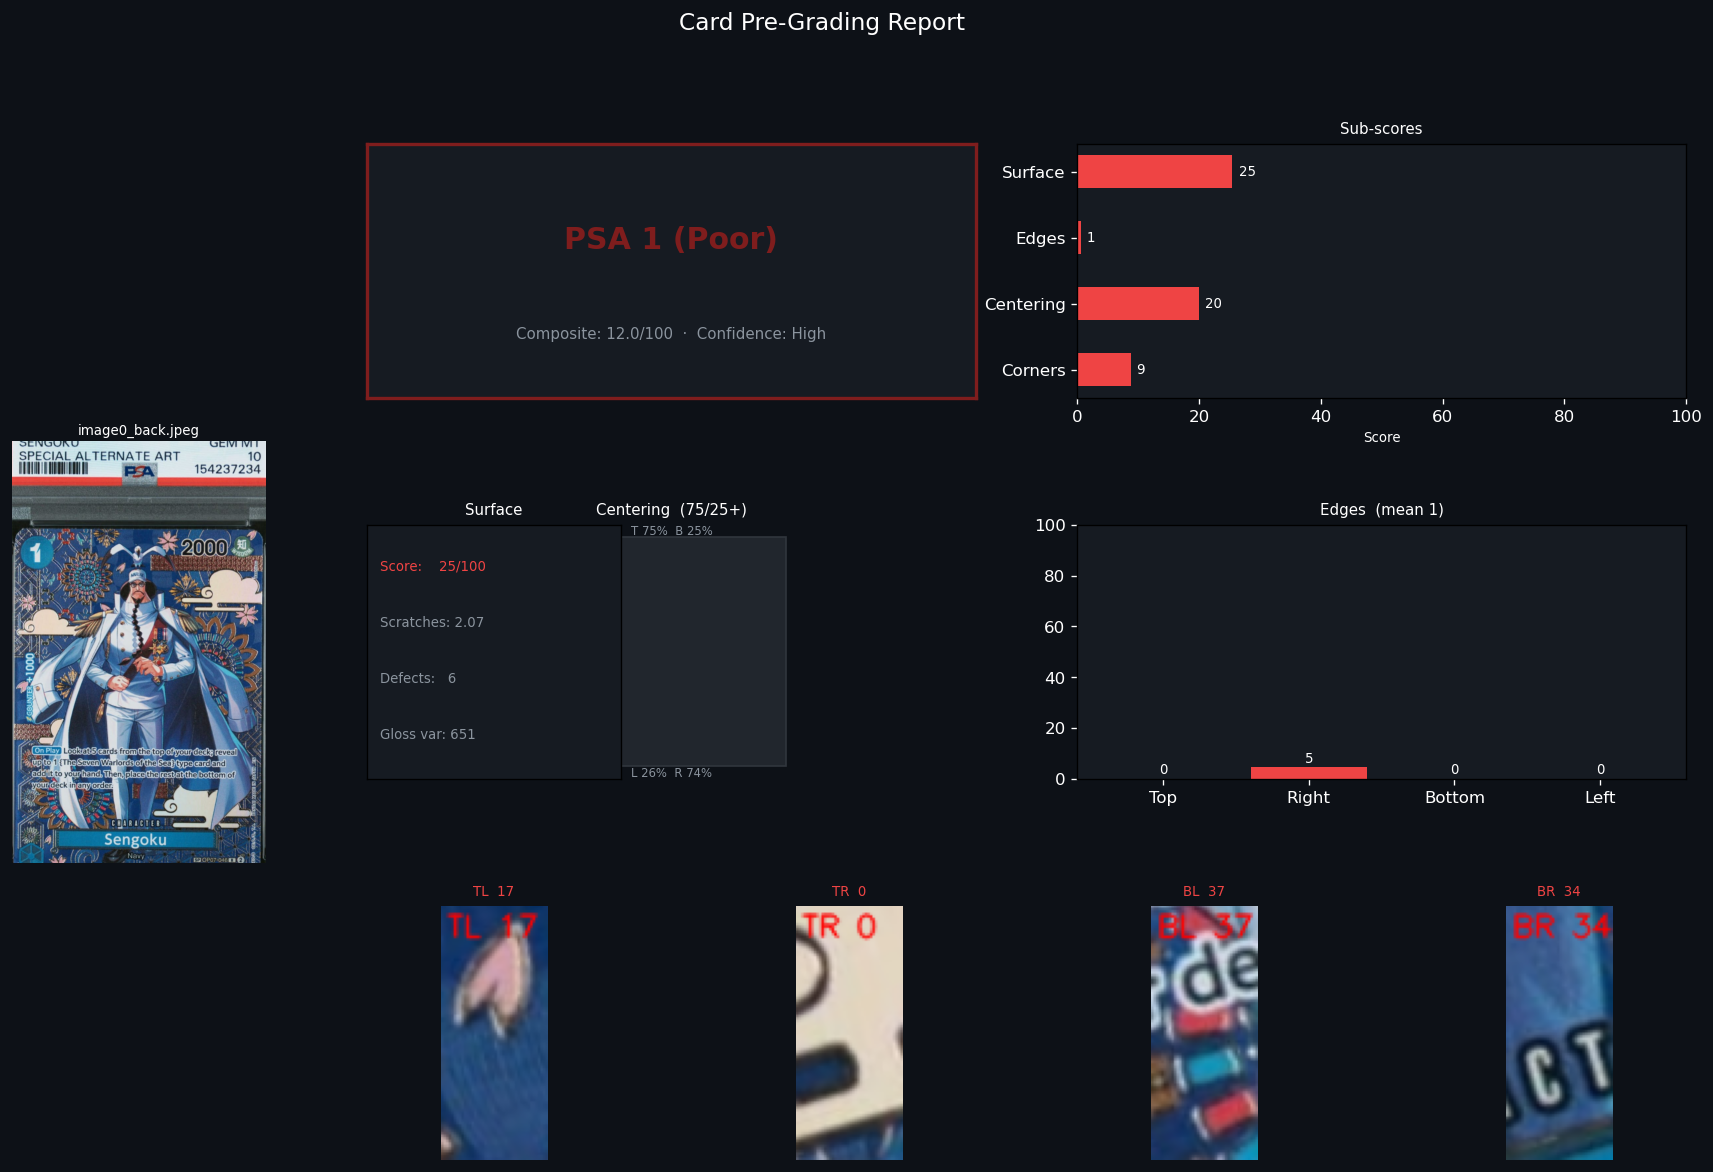

In [13]:
# Full visual dashboard
plot_report(report, IMAGE_PATH)

## 12. Batch Processing

Grade a folder of card images and export results to CSV.

In [14]:
import csv
from tqdm.notebook import tqdm

# ── CONFIG ────────────────────────────────────────────────────────
CARD_FOLDER  = Path('cards/')        # folder of card images
OUTPUT_CSV   = Path('grades.csv')    # output file
# ─────────────────────────────────────────────────────────────────

image_paths = sorted([
    p for p in CARD_FOLDER.iterdir()
    if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.webp')
])

print(f'Found {len(image_paths)} images in {CARD_FOLDER}')

results = []
for path in tqdm(image_paths, desc='Grading'):
    try:
        r = grade_card(str(path), yolo_model=yolo_model)
        results.append({
            'file':          path.name,
            'psa_estimate':  int(r.psa_estimate),
            'psa_label':     r.psa_label,
            'composite':     round(r.composite, 1),
            'corners':       round(r.sub_scores['corners'], 1),
            'centering':     round(r.sub_scores['centering'], 1),
            'centering_ratio': r.centering.grade,
            'edges':         round(r.sub_scores['edges'], 1),
            'surface':       round(r.sub_scores['surface'], 1),
            'confidence':    r.confidence,
        })
    except Exception as e:
        print(f'  ⚠ {path.name}: {e}')
        results.append({'file': path.name, 'psa_estimate': None, 'error': str(e)})

# Write CSV
if results:
    keys = [k for k in results[0] if k != 'error']
    with open(OUTPUT_CSV, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=keys + ['error'], extrasaction='ignore')
        w.writeheader()
        w.writerows(results)
    print(f'\n✅ Saved {len(results)} results to {OUTPUT_CSV}')

Found 3 images in cards


Grading:   0%|          | 0/3 [00:00<?, ?it/s]


✅ Saved 3 results to grades.csv


## 13. Grade Distribution (Batch Summary)

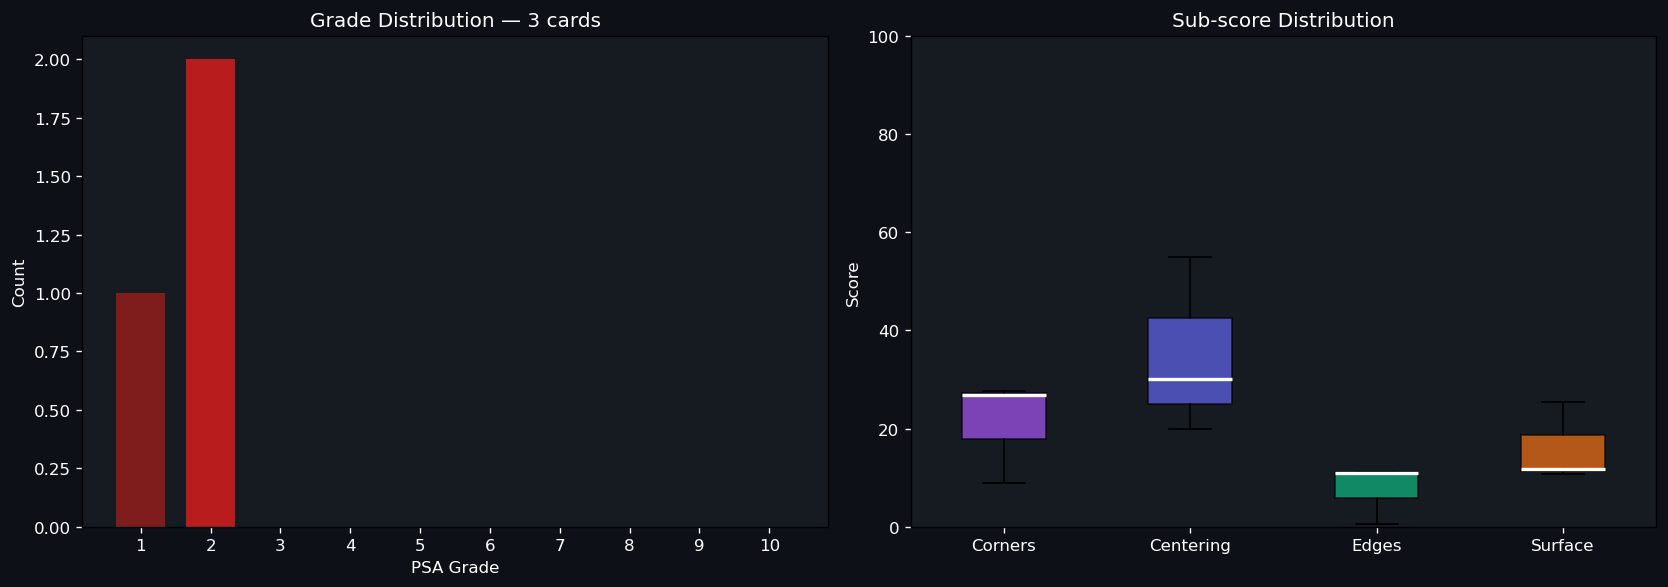


Median grade:   PSA 2
Mean grade:     PSA 1.7
PSA 9+ cards:   0 / 3
PSA 8+ cards:   0 / 3


In [15]:
if results:
    valid = [r for r in results if r.get('psa_estimate')]
    grades = [r['psa_estimate'] for r in valid]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0d1117')

    # ── Grade distribution bar chart ──────────────────────────────
    ax1 = axes[0]
    ax1.set_facecolor('#161b22')
    grade_counts = {g: grades.count(g) for g in range(1, 11)}
    ax1.bar(
        grade_counts.keys(),
        grade_counts.values(),
        color=[GRADE_COLORS[g] for g in grade_counts.keys()],
        width=0.7,
    )
    ax1.set_xlabel('PSA Grade', color='white')
    ax1.set_ylabel('Count', color='white')
    ax1.set_title(f'Grade Distribution — {len(valid)} cards', color='white')
    ax1.set_xticks(range(1, 11))
    ax1.tick_params(colors='white')

    # ── Sub-score box plots ───────────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor('#161b22')
    dims = ['corners', 'centering', 'edges', 'surface']
    data = [[r[d] for r in valid if d in r] for d in dims]
    bp   = ax2.boxplot(data, labels=[d.capitalize() for d in dims],
                       patch_artist=True, medianprops={'color': 'white', 'linewidth': 2})
    colors_box = ['#a855f7', '#6366f1', '#10b981', '#f97316']
    for patch, clr in zip(bp['boxes'], colors_box):
        patch.set_facecolor(clr)
        patch.set_alpha(0.7)
    ax2.set_ylabel('Score', color='white')
    ax2.set_title('Sub-score Distribution', color='white')
    ax2.set_ylim(0, 100)
    ax2.tick_params(colors='white')

    plt.tight_layout()
    plt.show()

    print(f'\nMedian grade:   PSA {int(np.median(grades))}')
    print(f'Mean grade:     PSA {np.mean(grades):.1f}')
    print(f'PSA 9+ cards:   {sum(1 for g in grades if g >= 9)} / {len(grades)}')
    print(f'PSA 8+ cards:   {sum(1 for g in grades if g >= 8)} / {len(grades)}')

## 14. Image Quality Pre-flight

Run before grading to catch photos that will produce unreliable results.
Checks resolution, blur level, and glare/reflection coverage.

In [16]:
def check_image_quality(image_path: str, min_short_side: int = 800) -> dict:
    """
    Pre-flight quality checks before grading.

    Returns dict with:
      resolution_ok  – short side >= min_short_side
      blur_score     – Laplacian variance (>100 good, <50 too blurry)
      glare_pct      – % of pixels near-saturated white
      issues         – list of human-readable warnings
      overall        – 'OK' / 'WARNING' / 'POOR'
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return {'error': f'Cannot read {image_path}'}

    h, w = img.shape[:2]
    short_side = min(h, w)
    issues = []

    # ── Resolution ───────────────────────────────────────────────
    resolution_ok = short_side >= min_short_side
    if not resolution_ok:
        issues.append(
            f'Low resolution ({short_side}px short side — aim for ≥{min_short_side}px)'
        )

    # ── Blur — Laplacian variance of grayscale ────────────────────
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur_score = float(cv2.Laplacian(gray, cv2.CV_32F).var())
    if blur_score < 50:
        issues.append(f'Image too blurry (sharpness {blur_score:.0f}; aim for >100)')
    elif blur_score < 100:
        issues.append(f'Moderate blur (sharpness {blur_score:.0f})')

    # ── Glare — near-saturated white pixels ─────────────────────
    # All three channels > threshold simultaneously = specular glare
    glare_mask = (
        (img[:, :, 0] > 245) &
        (img[:, :, 1] > 245) &
        (img[:, :, 2] > 245)
    )
    glare_pct = float(glare_mask.sum() / glare_mask.size)
    if glare_pct > 0.03:
        issues.append(f'Heavy glare ({glare_pct:.1%} of pixels overexposed)')
    elif glare_pct > 0.01:
        issues.append(f'Light glare detected ({glare_pct:.1%} of pixels overexposed)')

    # ── Aspect ratio sanity ──────────────────────────────────────
    ratio = max(h, w) / max(min(h, w), 1)
    if ratio > 3.5:
        issues.append(
            f'Unusual aspect ratio ({ratio:.1f}:1) — crop tighter around the card'
        )

    overall = 'OK' if not issues else ('WARNING' if len(issues) == 1 else 'POOR')

    return {
        'resolution': (w, h),
        'short_side': short_side,
        'resolution_ok': resolution_ok,
        'blur_score': round(blur_score, 1),
        'glare_pct': round(glare_pct * 100, 2),
        'issues': issues,
        'overall': overall,
    }


def print_quality_report(qr: dict):
    STATUS = {'OK': '✅', 'WARNING': '⚠️', 'POOR': '❌'}
    icon = STATUS.get(qr.get('overall', ''), '?')
    print(f'\n{icon}  Quality: {qr.get("overall", "ERROR")}')
    print(f'   Resolution : {qr.get("resolution")}  (short side {qr.get("short_side")}px)')
    print(f'   Blur score : {qr.get("blur_score")}  (>100 = sharp)')
    print(f'   Glare      : {qr.get("glare_pct")}%')
    for issue in qr.get('issues', []):
        print(f'   ⚠ {issue}')
    print()

print('✅ Quality checker ready')

✅ Quality checker ready


## 15. Lighting Normalization

Reduces grading variance caused by:
- Inconsistent ambient light color (warm vs cool)
- Uneven exposure (corners darker)
- Specular glare from foil or sleeves

`normalize_lighting()` should be called on the **warped card** before any analysis.

In [17]:
def normalize_lighting(image: np.ndarray) -> np.ndarray:
    """
    Normalize lighting for consistent analysis.

    Steps
    -----
    1. CLAHE on L channel (LAB) — enhance local contrast, flatten uneven exposure
    2. Gray World white balance  — remove color cast from ambient lighting
    """
    if image.size == 0:
        return image

    # ── 1. CLAHE ─────────────────────────────────────────────────
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    corrected = cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2BGR)

    # ── 2. Gray World white balance ───────────────────────────────
    b_m = np.mean(corrected[:, :, 0])
    g_m = np.mean(corrected[:, :, 1])
    r_m = np.mean(corrected[:, :, 2])
    overall = (b_m + g_m + r_m) / 3.0

    balanced = corrected.astype(np.float32)
    balanced[:, :, 0] *= overall / max(b_m, 1)
    balanced[:, :, 1] *= overall / max(g_m, 1)
    balanced[:, :, 2] *= overall / max(r_m, 1)
    return np.clip(balanced, 0, 255).astype(np.uint8)


def remove_glare(image: np.ndarray, threshold: int = 242) -> np.ndarray:
    """
    Replace specular glare spots with inpainted texture.
    Uses Navier-Stokes inpainting; leaves non-glare regions untouched.
    """
    glare_mask = (
        (image[:, :, 0] > threshold) &
        (image[:, :, 1] > threshold) &
        (image[:, :, 2] > threshold)
    ).astype(np.uint8) * 255

    if glare_mask.sum() == 0:
        return image

    # Dilate to cover the halo around the specular peak
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    glare_mask = cv2.dilate(glare_mask, kernel, iterations=2)

    return cv2.inpaint(image, glare_mask, inpaintRadius=9, flags=cv2.INPAINT_NS)


def show_normalization_comparison(image_path: str):
    """Side-by-side before/after visualization of lighting normalization."""
    _, card, _ = extract_card(image_path)
    norm  = normalize_lighting(card)
    dglare = remove_glare(norm)

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.patch.set_facecolor('#0d1117')
    titles = ['Original (warped)', 'CLAHE + White Balance', '+ Glare Removal']
    imgs   = [card, norm, dglare]
    for ax, title, img in zip(axes, titles, imgs):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, color='white', fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('✅ Lighting normalizer ready')

✅ Lighting normalizer ready


## 16. Per-Card-Type Configuration

Different trading card games have different:
- **Centering standards** (PSA grades Pokémon more strictly than vintage baseball)
- **Border widths** (some sets have very thin borders)
- **Aspect ratios** (MTG is the same; Yu-Gi-Oh slightly different)
- **Border color expectations** (white vs yellow vs black)

Pass a `CardTypeConfig` to `grade_card()` to apply game-specific tolerances.

In [18]:
from dataclasses import dataclass as _dc

@_dc
class CardTypeConfig:
    name:                    str
    # Centering ratio thresholds for PSA 10 / PSA 9 (larger_side / smaller_side)
    psa10_centering_ratio:   float   # e.g. 1.10 = 55/45
    psa9_centering_ratio:    float   # e.g. 1.22 = 55/45 lenient
    # Expected border as fraction of card dimension
    min_border_frac:         float
    max_border_frac:         float
    # Card aspect ratio (height/width) and tolerance
    aspect_ratio:            float
    aspect_tolerance:        float
    # Corner sharpness baseline (higher = sharper corners expected)
    corner_sharpness_target: float
    # Does this card type commonly have foil? (foil raises surface gloss baseline)
    has_foil_variants:       bool


CARD_CONFIGS: dict[str, CardTypeConfig] = {
    'pokemon': CardTypeConfig(
        name                   = 'Pokémon TCG',
        psa10_centering_ratio  = 1.10,   # 55/45 — very strict
        psa9_centering_ratio   = 1.22,
        min_border_frac        = 0.05,
        max_border_frac        = 0.12,
        aspect_ratio           = 88 / 63,
        aspect_tolerance       = 0.12,
        corner_sharpness_target= 150.0,
        has_foil_variants      = True,
    ),
    'sports': CardTypeConfig(
        name                   = 'Sports Card (modern)',
        psa10_centering_ratio  = 1.10,
        psa9_centering_ratio   = 1.22,
        min_border_frac        = 0.04,
        max_border_frac        = 0.10,
        aspect_ratio           = 89 / 64,  # standard US sports card
        aspect_tolerance       = 0.10,
        corner_sharpness_target= 180.0,
        has_foil_variants      = False,
    ),
    'mtg': CardTypeConfig(
        name                   = 'Magic: The Gathering',
        psa10_centering_ratio  = 1.22,   # slightly more lenient than Pokémon
        psa9_centering_ratio   = 1.40,
        min_border_frac        = 0.04,
        max_border_frac        = 0.09,
        aspect_ratio           = 88 / 63,
        aspect_tolerance       = 0.12,
        corner_sharpness_target= 160.0,
        has_foil_variants      = True,
    ),
    'yugioh': CardTypeConfig(
        name                   = 'Yu-Gi-Oh!',
        psa10_centering_ratio  = 1.22,
        psa9_centering_ratio   = 1.40,
        min_border_frac        = 0.03,
        max_border_frac        = 0.08,
        aspect_ratio           = 86 / 59,
        aspect_tolerance       = 0.12,
        corner_sharpness_target= 150.0,
        has_foil_variants      = True,
    ),
}

DEFAULT_CONFIG = CARD_CONFIGS['pokemon']


def centering_score_with_config(h_ratio: float, v_ratio: float,
                                 cfg: CardTypeConfig) -> float:
    """
    Score centering using game-specific PSA thresholds.
    Produces 0-100 same as original but respects the card type's tolerance.
    """
    p10 = cfg.psa10_centering_ratio
    p9  = cfg.psa9_centering_ratio
    # Build threshold ladder anchored to this card type's standards
    def _score(ratio: float) -> float:
        r = max(ratio, 1 / max(ratio, 1e-6))
        if r <= p10:        return 100.0
        if r <= p9:         return  90.0
        if r <= p9 * 1.15:  return  80.0
        if r <= p9 * 1.30:  return  65.0
        if r <= p9 * 1.65:  return  50.0
        if r <= p9 * 2.05:  return  35.0
        return 15.0
    return (_score(h_ratio) + _score(v_ratio)) / 2.0


print('✅ Card type configs ready')
print('Available types:', list(CARD_CONFIGS.keys()))

✅ Card type configs ready
Available types: ['pokemon', 'sports', 'mtg', 'yugioh']


## 17. Improved Centering — Projection Profile Method

The original centering algorithm scans for color change in LAB space.
It fails when the border color is similar to the card artwork (e.g. dark-bordered MTG cards).

**Projection profile method:**
1. Convert to grayscale and compute Sobel gradient magnitude
2. Collapse to 1D row/column profiles by summing gradient across the perpendicular axis
3. The border-to-artwork transition shows up as a sharp spike in the profile
4. Find the first and last major spike from each edge — those are the border boundaries

This works regardless of border color.

In [19]:
def analyze_centering_projection(card: np.ndarray,
                                  cfg: CardTypeConfig = DEFAULT_CONFIG) -> CenteringResult:
    """
    Robust centering via Sobel gradient projection profiles.
    More reliable than color-scanning for dark or unusual border colors.
    """
    h, w = card.shape[:2]

    # ── Gradient magnitude ────────────────────────────────────────
    gray = cv2.cvtColor(card, cv2.COLOR_BGR2GRAY)
    sx   = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sy   = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag  = np.sqrt(sx**2 + sy**2)

    # ── 1D profiles ───────────────────────────────────────────────
    # Row profile: sum gradient across columns → peaks = horizontal edge rows
    row_prof = mag.sum(axis=1)      # shape (h,)
    # Col profile: sum gradient across rows → peaks = vertical edge columns
    col_prof = mag.sum(axis=0)      # shape (w,)

    # Smooth with a mild Gaussian kernel to suppress per-pixel noise
    k = max(5, min(w, h) // 20)
    k = k if k % 2 == 1 else k + 1
    row_prof = cv2.GaussianBlur(row_prof.reshape(-1, 1).astype(np.float32),
                                 (1, k), 0).flatten()
    col_prof = cv2.GaussianBlur(col_prof.reshape(-1, 1).astype(np.float32),
                                 (1, k), 0).flatten()

    def _first_peak(profile: np.ndarray, search_frac: float = 0.30) -> int:
        """Return index of first significant peak from the start."""
        n  = len(profile)
        end = int(n * search_frac)
        if end < 2:
            return 1
        chunk = profile[:end]
        thresh = chunk.max() * 0.35
        for i in range(1, end - 1):
            if chunk[i] >= thresh and chunk[i] >= chunk[i-1] and chunk[i] >= chunk[i+1]:
                return i
        return max(1, int(n * 0.05))   # fallback: 5% of dimension

    def _last_peak(profile: np.ndarray, search_frac: float = 0.30) -> int:
        """Return index of last significant peak from the end."""
        n   = len(profile)
        start = int(n * (1 - search_frac))
        chunk = profile[start:]
        thresh = chunk.max() * 0.35
        for i in range(len(chunk) - 2, 0, -1):
            if chunk[i] >= thresh and chunk[i] >= chunk[i-1] and chunk[i] >= chunk[i+1]:
                return start + i
        return min(n - 2, int(n * 0.95))

    top_px    = _first_peak(row_prof)
    bottom_px = _last_peak(row_prof)
    left_px   = _first_peak(col_prof)
    right_px  = _last_peak(col_prof)

    # Clamp to sane range
    top_px    = max(1, min(top_px,    h // 4))
    bottom_px = max(3 * h // 4, min(bottom_px, h - 2))
    left_px   = max(1, min(left_px,   w // 4))
    right_px  = max(3 * w // 4, min(right_px,  w - 2))

    left_w  = left_px
    right_w = w - right_px
    top_w   = top_px
    bot_w   = h - bottom_px

    total_h = max(left_w + right_w, 1)
    total_v = max(top_w  + bot_w,   1)

    left_pct   = left_w  / total_h
    right_pct  = right_w / total_h
    top_pct    = top_w   / total_v
    bottom_pct = bot_w   / total_v

    h_ratio = left_pct  / max(right_pct,  1e-6)
    v_ratio = top_pct   / max(bottom_pct, 1e-6)

    score = centering_score_with_config(h_ratio, v_ratio, cfg)
    r = max(max(h_ratio, 1 / max(h_ratio, 1e-6)),
            max(v_ratio, 1 / max(v_ratio, 1e-6)))
    grade = ('55/45' if r <= 1.22 else
             '60/40' if r <= 1.50 else
             '65/35' if r <= 1.86 else
             '70/30' if r <= 2.33 else '75/25+')

    return CenteringResult(
        left_pct=left_pct, right_pct=right_pct,
        top_pct=top_pct,   bottom_pct=bottom_pct,
        h_ratio=h_ratio,   v_ratio=v_ratio,
        score=score,       grade=grade,
    )


def show_centering_profiles(image_path: str):
    """Visualize the row/col gradient profiles used for centering detection."""
    _, card, _ = extract_card(image_path)
    h, w = card.shape[:2]
    gray = cv2.cvtColor(card, cv2.COLOR_BGR2GRAY)
    sx   = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sy   = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag  = np.sqrt(sx**2 + sy**2)
    row_prof = mag.sum(axis=1)
    col_prof = mag.sum(axis=0)

    result = analyze_centering_projection(card)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor('#0d1117')

    axes[0].imshow(cv2.cvtColor(card, cv2.COLOR_BGR2RGB))
    axes[0].axhline(result.top_pct    * h, color='#22c55e', lw=1.5, label='top')
    axes[0].axhline((1-result.bottom_pct) * h, color='#22c55e', lw=1.5, ls='--', label='bottom')
    axes[0].axvline(result.left_pct   * w, color='#f59e0b', lw=1.5, label='left')
    axes[0].axvline((1-result.right_pct)  * w, color='#f59e0b', lw=1.5, ls='--', label='right')
    axes[0].set_title(f'Detected borders  ({result.grade})', color='white')
    axes[0].axis('off')

    axes[1].set_facecolor('#161b22')
    axes[1].plot(row_prof, np.arange(h), color='#6366f1')
    axes[1].invert_yaxis()
    axes[1].set_title('Row gradient profile (vertical)', color='white')
    axes[1].tick_params(colors='white')

    axes[2].set_facecolor('#161b22')
    axes[2].plot(col_prof, color='#f59e0b')
    axes[2].set_title('Column gradient profile (horizontal)', color='white')
    axes[2].tick_params(colors='white')

    plt.tight_layout()
    plt.show()

print('✅ Projection-profile centering ready')

✅ Projection-profile centering ready


## 18. Feature Extraction for ML Calibration

Turns a `GradeReport` into a fixed-length numpy feature vector.
Used by both the calibration model and any downstream analysis.

In [20]:
FEATURE_NAMES = [
    # Corners (4 individual + summary)
    'corner_TL', 'corner_TR', 'corner_BL', 'corner_BR',
    'corner_mean', 'corner_worst', 'corner_std',
    # Edges (4 individual + summary)
    'edge_top', 'edge_right', 'edge_bottom', 'edge_left',
    'edge_mean', 'edge_worst',
    # Centering
    'centering_h_ratio', 'centering_v_ratio', 'centering_score',
    # Surface
    'surface_scratch_density', 'surface_defect_count', 'surface_score',
    # Overall
    'composite_score',
]

def extract_features(report: GradeReport) -> np.ndarray:
    """
    Convert a GradeReport to a 20-element float32 feature vector.
    Order matches FEATURE_NAMES.
    """
    c   = report.corners
    e   = report.edges
    cen = report.centering
    s   = report.surface

    # Pad corner/edge scores to exactly 4 in case fewer were computed
    cs = (c.scores + [c.mean] * 4)[:4]
    es = (e.scores + [e.mean] * 4)[:4]

    return np.array([
        *cs,                           # 0-3
        c.mean,                        # 4
        c.worst,                       # 5
        float(np.std(cs)),             # 6
        *es,                           # 7-10
        e.mean,                        # 11
        e.worst,                       # 12
        cen.h_ratio,                   # 13
        cen.v_ratio,                   # 14
        cen.score,                     # 15
        s.scratch_density,             # 16
        float(s.defect_count),         # 17
        s.score,                       # 18
        report.composite,              # 19
    ], dtype=np.float32)


def plot_feature_vector(report: GradeReport):
    """Bar chart of the feature vector for a single card."""
    vec = extract_features(report)
    fig, ax = plt.subplots(figsize=(14, 4))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')
    colors = ['#22c55e' if v >= 70 else '#fbbf24' if v >= 45 else '#ef4444'
              for v in vec]
    ax.bar(range(len(vec)), vec, color=colors)
    ax.set_xticks(range(len(FEATURE_NAMES)))
    ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha='right', fontsize=7, color='white')
    ax.set_ylim(0, max(vec.max() * 1.15, 110))
    ax.set_title(f'Feature vector — {Path(report.image_path).name}', color='white')
    ax.tick_params(colors='white')
    plt.tight_layout()
    plt.show()

print('✅ Feature extractor ready  —', len(FEATURE_NAMES), 'features')

✅ Feature extractor ready  — 20 features


## 19. Calibration Model (GradientBoosting → PSA Grade)

Once you've graded **≥20 real slabs**, train this model to calibrate the
rule-based score against actual PSA outcomes.
The model learns which CV features matter most for your cards.

With <20 slabs it still trains but will overfit — use synthetic data
to supplement (see Section 20).

In [21]:
class CalibrationModel:
    """
    GradientBoostingRegressor trained on (GradeReport → true PSA grade).
    Falls back to composite_to_psa() rule-based logic if not trained.
    """

    def __init__(self):
        self.pipeline = None
        self.trained   = False
        self.importances: dict = {}

    # ── Training ─────────────────────────────────────────────────
    def train(self, reports: list, true_grades: list[int]):
        """
        Args
        ----
        reports:     list of GradeReport (from grade_card())
        true_grades: matching list of int PSA grades (1-10)
        """
        from sklearn.ensemble import GradientBoostingRegressor
        from sklearn.preprocessing import RobustScaler
        from sklearn.pipeline import Pipeline
        from sklearn.model_selection import cross_val_score

        X = np.array([extract_features(r) for r in reports])
        y = np.array(true_grades, dtype=np.float32)

        self.pipeline = Pipeline([
            ('scaler', RobustScaler()),
            ('gbr', GradientBoostingRegressor(
                n_estimators  = 300,
                max_depth     = 4,
                learning_rate = 0.04,
                subsample     = 0.80,
                min_samples_leaf = 3,
                random_state  = 42,
            )),
        ])

        if len(X) >= 5:
            cv_scores = cross_val_score(
                self.pipeline, X, y,
                cv=min(5, len(X)),
                scoring='neg_mean_absolute_error',
            )
            print(f'Cross-val MAE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f} PSA grades')

        self.pipeline.fit(X, y)
        self.trained = True

        gbr = self.pipeline.named_steps['gbr']
        self.importances = dict(zip(FEATURE_NAMES, gbr.feature_importances_))
        top5 = sorted(self.importances.items(), key=lambda x: -x[1])[:5]
        print(f'✅ Trained on {len(X)} samples')
        print('Top features:', ', '.join(f'{k}({v:.2f})' for k, v in top5))

    # ── Prediction ───────────────────────────────────────────────
    def predict(self, report: GradeReport) -> int:
        """Return predicted PSA grade 1-10."""
        if not self.trained:
            return int(composite_to_psa(report.composite, report.corners.worst))
        X = extract_features(report).reshape(1, -1)
        pred = float(self.pipeline.predict(X)[0])
        return int(round(max(1.0, min(10.0, pred))))

    def predict_proba_approx(self, report: GradeReport) -> dict:
        """
        Approximate per-grade probability by perturbing features slightly
        and seeing how the prediction shifts (poor-man's uncertainty).
        Real uncertainty requires a probabilistic model (see Section 20).
        """
        if not self.trained:
            base = self.predict(report)
            return {g: (0.6 if g == base else 0.1 if abs(g-base)==1 else 0.02)
                    for g in range(1, 11)}
        rng  = np.random.default_rng(0)
        base = extract_features(report)
        preds = []
        for _ in range(50):
            noisy = base + rng.normal(0, 2, size=base.shape).astype(np.float32)
            p = float(self.pipeline.predict(noisy.reshape(1, -1))[0])
            preds.append(int(round(np.clip(p, 1, 10))))
        counts = {g: preds.count(g) / len(preds) for g in range(1, 11)}
        return counts

    # ── Persistence ──────────────────────────────────────────────
    def save(self, path: str = 'calibration_model.pkl'):
        import pickle
        with open(path, 'wb') as f:
            pickle.dump(self.pipeline, f)
        print(f'✅ Model saved → {path}')

    def load(self, path: str = 'calibration_model.pkl'):
        import pickle
        with open(path, 'rb') as f:
            self.pipeline = pickle.load(f)
        self.trained = True
        print(f'✅ Model loaded ← {path}')

    def plot_importances(self):
        if not self.importances:
            print('Train model first.'); return
        sorted_imp = sorted(self.importances.items(), key=lambda x: x[1])
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor('#0d1117')
        ax.set_facecolor('#161b22')
        ax.barh([k for k, _ in sorted_imp],
                [v for _, v in sorted_imp],
                color='#6366f1')
        ax.set_xlabel('Feature importance', color='white')
        ax.set_title('Calibration Model — Feature Importances', color='white')
        ax.tick_params(colors='white')
        plt.tight_layout(); plt.show()


# ── Global instance ───────────────────────────────────────────────
calibration_model = CalibrationModel()
print('✅ CalibrationModel ready (not yet trained — see Section 20)')

✅ CalibrationModel ready (not yet trained — see Section 20)


## 20. Synthetic Training Data + Demo Training

Generates realistic synthetic grades to bootstrap the calibration model
before real labeled data is available.

**To replace with real data:**
```python
reports    = [grade_card(path) for path in my_image_paths]
true_grades = [9, 7, 8, 10, ...]   # your actual PSA grades
calibration_model.train(reports, true_grades)
```

Generating 600 synthetic training samples...
Grade distribution: {1: 34, 2: 146, 3: 43, 4: 75, 5: 60, 6: 65, 7: 68, 8: 48, 9: 40, 10: 21}

Training calibration model...
Cross-val MAE: 0.39 ± 0.02 PSA grades
✅ Trained on 600 samples
Top features: corner_worst(0.73), composite_score(0.23), corner_std(0.01), corner_BL(0.00), surface_scratch_density(0.00)


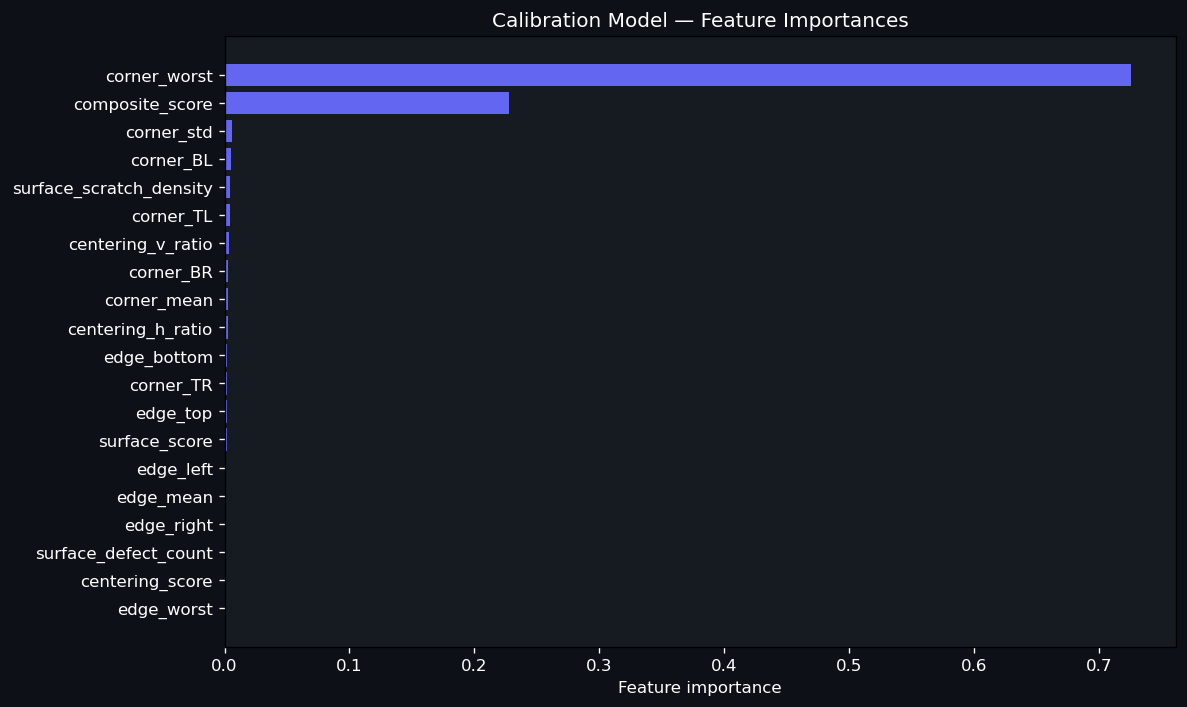

In [22]:
def generate_synthetic_training_data(n: int = 600, seed: int = 42) -> tuple:
    """
    Produce (reports, grades) lists by simulating cards across the full quality range.

    Correlations modelled
    ---------------------
    - Quality → corners, edges, surface are correlated (wear affects all)
    - Centering is independent of physical wear
    - One-corner damage is modelled separately (common PSA grade-limiter)
    - Grader variance: ±1 grade with 20% probability
    """
    rng = np.random.default_rng(seed)

    class _Mock:
        """Lightweight mock that satisfies extract_features() ducktype."""
        pass

    reports, grades = [], []

    for _ in range(n):
        quality = rng.uniform(5, 100)     # card condition 0-100

        # ── Corners ──────────────────────────────────────────────
        base_corner = quality * rng.uniform(0.85, 1.15)
        corner_scores = np.clip(
            base_corner + rng.normal(0, 6, 4), 0, 100
        ).tolist()
        # 15% chance of one bad corner (ding, bend)
        if rng.random() < 0.15:
            worst_idx = rng.integers(0, 4)
            corner_scores[worst_idx] = max(
                0, corner_scores[worst_idx] - rng.uniform(25, 55)
            )
        corners = _Mock()
        corners.scores = corner_scores
        corners.mean   = float(np.mean(corner_scores))
        corners.worst  = float(np.min(corner_scores))
        corners.images = []

        # ── Edges ────────────────────────────────────────────────
        edge_scores = np.clip(
            base_corner * 0.95 + rng.normal(0, 5, 4), 0, 100
        ).tolist()
        edges = _Mock()
        edges.scores = edge_scores
        edges.mean   = float(np.mean(edge_scores))
        edges.worst  = float(np.min(edge_scores))

        # ── Centering (independent) ───────────────────────────────
        cen_class = rng.choice(['gem', 'good', 'off'], p=[0.40, 0.38, 0.22])
        h_ratio = {'gem':  rng.uniform(1.0,  1.12),
                   'good': rng.uniform(1.12, 1.55),
                   'off':  rng.uniform(1.55, 3.00)}[cen_class]
        v_ratio = {'gem':  rng.uniform(1.0,  1.12),
                   'good': rng.uniform(1.12, 1.55),
                   'off':  rng.uniform(1.55, 3.00)}[cen_class]

        def _cen_score(r):
            r = max(r, 1/max(r, 1e-9))
            return (100 if r<=1.10 else 90 if r<=1.22 else
                    80 if r<=1.40 else 65 if r<=1.60 else
                    50 if r<=2.00 else 35 if r<=2.50 else 15)

        cen_score = (_cen_score(h_ratio) + _cen_score(v_ratio)) / 2
        r_max = max(h_ratio, 1/h_ratio, v_ratio, 1/v_ratio)
        cen_grade = ('55/45' if r_max<=1.22 else '60/40' if r_max<=1.50 else
                     '65/35' if r_max<=1.86 else '70/30' if r_max<=2.33 else '75/25+')

        centering = _Mock()
        centering.left_pct = centering.right_pct = 0.5
        centering.top_pct  = centering.bottom_pct = 0.5
        centering.h_ratio  = h_ratio
        centering.v_ratio  = v_ratio
        centering.score    = cen_score
        centering.grade    = cen_grade

        # ── Surface ───────────────────────────────────────────────
        surf_score   = float(np.clip(quality * 0.88 + rng.normal(0, 9), 0, 100))
        scratch_d    = float(np.clip(rng.exponential(0.4*(1-quality/100)), 0, 6))
        defect_n     = int(np.clip(rng.poisson((1-quality/100)*4), 0, 25))
        surface = _Mock()
        surface.scratch_density = scratch_d
        surface.gloss_variance  = float(rng.uniform(50, 500))
        surface.defect_count    = defect_n
        surface.score           = surf_score

        # ── Composite → PSA (rule-based) ──────────────────────────
        corner_s  = corners.mean * 0.4 + corners.worst * 0.6
        edge_s    = edges.mean   * 0.5 + edges.worst   * 0.5
        sub = {'corners': corner_s, 'centering': cen_score,
               'edges': edge_s,    'surface': surf_score}
        composite = sum(sub[k] * WEIGHTS[k] for k in WEIGHTS)
        psa_base  = composite_to_psa(composite, corners.worst)

        # ── Grader variance ± 1 (20% chance) ─────────────────────
        delta     = rng.choice([-1, 0, 0, 0, 1], p=[0.10, 0.25, 0.30, 0.25, 0.10])
        psa_noisy = int(np.clip(psa_base + delta, 1, 10))

        report = GradeReport(
            image_path  = 'synthetic',
            centering   = centering,
            corners     = corners,
            edges       = edges,
            surface     = surface,
            sub_scores  = sub,
            composite   = composite,
            psa_estimate= float(psa_base),
            psa_label   = f'PSA {int(psa_base)}',
            confidence  = 'High',
        )
        reports.append(report)
        grades.append(psa_noisy)

    return reports, grades


# ── Generate synthetic data and train the calibration model ──────
print('Generating 600 synthetic training samples...')
syn_reports, syn_grades = generate_synthetic_training_data(n=600)

from collections import Counter
dist = Counter(syn_grades)
print('Grade distribution:', dict(sorted(dist.items())))

print('\nTraining calibration model...')
calibration_model.train(syn_reports, syn_grades)

# Feature importance chart
calibration_model.plot_importances()

## 21. Improved `grade_card_v2()` — Full Pipeline

Wires together all improvements:
- Pre-flight quality check
- Lighting normalization + glare removal
- Projection-profile centering (more robust)
- Card-type config (PSA thresholds per game)
- Calibration model (when trained on real data)

In [23]:
def grade_card_v2(
    image_path: str,
    yolo_model=None,
    card_type: str = 'pokemon',
    use_calibration: bool = True,
    normalize: bool = True,
    skip_quality_check: bool = False,
) -> tuple[GradeReport, dict]:
    """
    Improved grading pipeline with all enhancements.

    Parameters
    ----------
    image_path       : path to card photo
    yolo_model       : loaded YOLO model or None for contour-only
    card_type        : key in CARD_CONFIGS ('pokemon','sports','mtg','yugioh')
    use_calibration  : use the ML calibration model if trained
    normalize        : apply lighting normalization before analysis
    skip_quality_check: skip the pre-flight check (faster)

    Returns
    -------
    (GradeReport, quality_report_dict)
    """
    cfg = CARD_CONFIGS.get(card_type, DEFAULT_CONFIG)

    # ── Pre-flight quality check ──────────────────────────────────
    qr = {} if skip_quality_check else check_image_quality(image_path)
    if qr.get('overall') == 'POOR':
        print(f'⚠  Image quality is POOR — results may be unreliable')
        for issue in qr.get('issues', []):
            print(f'   • {issue}')

    # ── Card detection & deskew ───────────────────────────────────
    _, card, method = extract_card(image_path, yolo_model)

    # ── Lighting normalization (optional but recommended) ─────────
    if normalize:
        card = remove_glare(card)
        card = normalize_lighting(card)

    # ── Analysis ─────────────────────────────────────────────────
    centering = analyze_centering_projection(card, cfg)   # improved
    corners   = analyze_corners(card)
    edges     = analyze_edges(card)
    surface   = analyze_surface(card)

    corner_score = corners.mean * 0.4 + corners.worst * 0.6
    edge_score   = edges.mean   * 0.5 + edges.worst   * 0.5

    sub_scores = {
        'corners':   corner_score,
        'centering': centering.score,
        'edges':     edge_score,
        'surface':   surface.score,
    }

    composite = sum(sub_scores[k] * WEIGHTS[k] for k in WEIGHTS)

    # ── Grade prediction ──────────────────────────────────────────
    if use_calibration and calibration_model.trained:
        # Build a partial report to pass to calibration model
        partial = GradeReport(
            image_path=str(image_path), centering=centering,
            corners=corners, edges=edges, surface=surface,
            sub_scores=sub_scores, composite=composite,
            psa_estimate=0, psa_label='', confidence='',
        )
        psa_est = calibration_model.predict(partial)
        confidence = 'High' if method != 'center_crop' else 'Medium'
    else:
        psa_est   = composite_to_psa(composite, corners.worst)
        confidence = 'Low' if method == 'center_crop' else 'High'

    psa_int   = int(psa_est)
    psa_label = f'PSA {psa_int} ({PSA_LABELS[psa_int]})'

    report = GradeReport(
        image_path   = str(image_path),
        centering    = centering,
        corners      = corners,
        edges        = edges,
        surface      = surface,
        sub_scores   = sub_scores,
        composite    = composite,
        psa_estimate = float(psa_est),
        psa_label    = psa_label,
        confidence   = confidence,
    )
    return report, qr


print('✅ grade_card_v2() ready')
print('\nUsage:')
print('  report, qr = grade_card_v2("image0_back.jpeg", yolo_model, card_type="pokemon")')
print('  print_quality_report(qr)')
print('  plot_report(report, "image0_back.jpeg")')

✅ grade_card_v2() ready

Usage:
  report, qr = grade_card_v2("image0_back.jpeg", yolo_model, card_type="pokemon")
  print_quality_report(qr)
  plot_report(report, "image0_back.jpeg")


## 22. Demo — Run All Improvements on a Card


⚠️  Quality: WARNING
   Resolution : (951, 1600)  (short side 951px)
   Blur score : 1495.6  (>100 = sharp)
   Glare      : 3.06%
   ⚠ Heavy glare (3.1% of pixels overexposed)



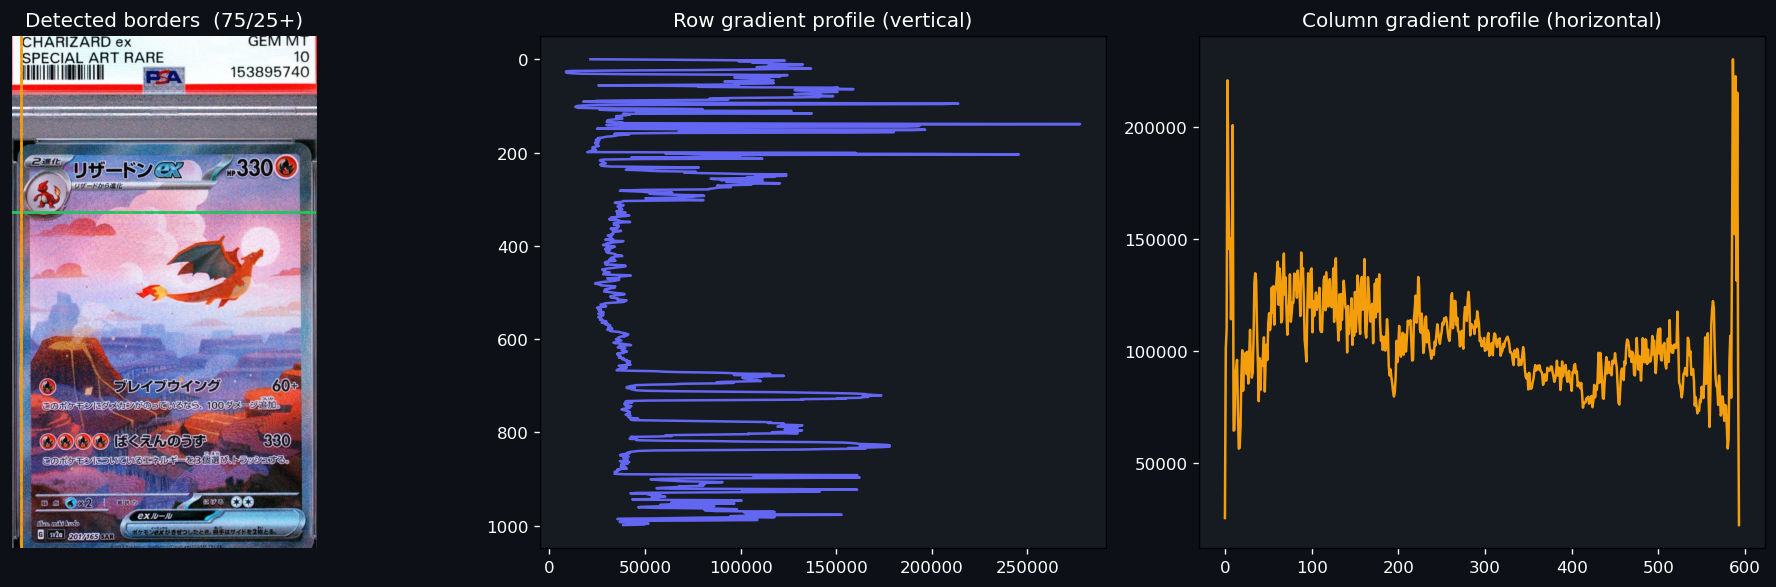

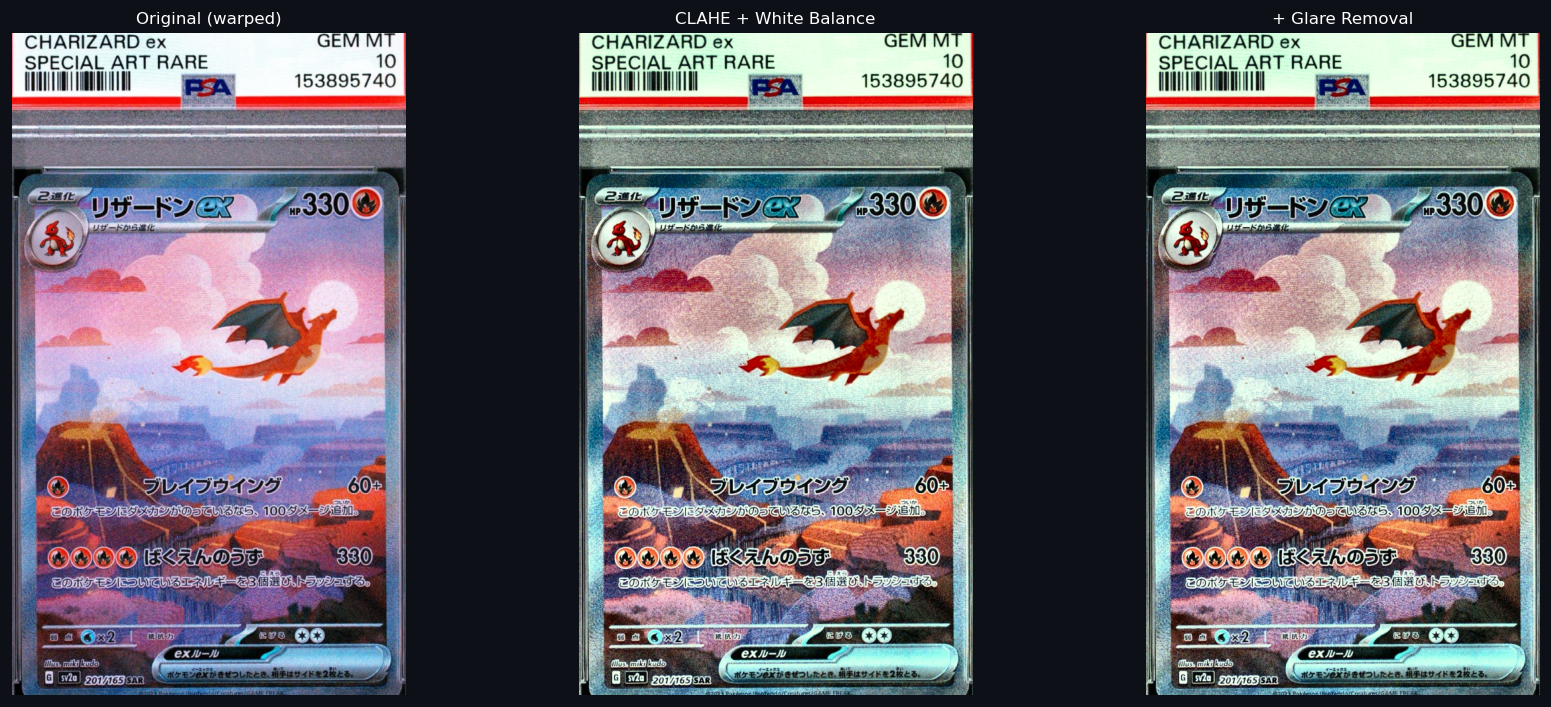


────────────────────────────────────────────────────
  PSA 3 (Very Good)
  Composite : 29.2 / 100
  Confidence: Medium
  Centering : 70/30  (h=1.20  v=0.48)
  Corners   : mean 34.9  worst 31.6
  Edges     : mean 1.7   worst 0.0
  Surface   : 6.6
  Detection : YOLO
  Calibrated: True
─────────────────────────────────────────────────────


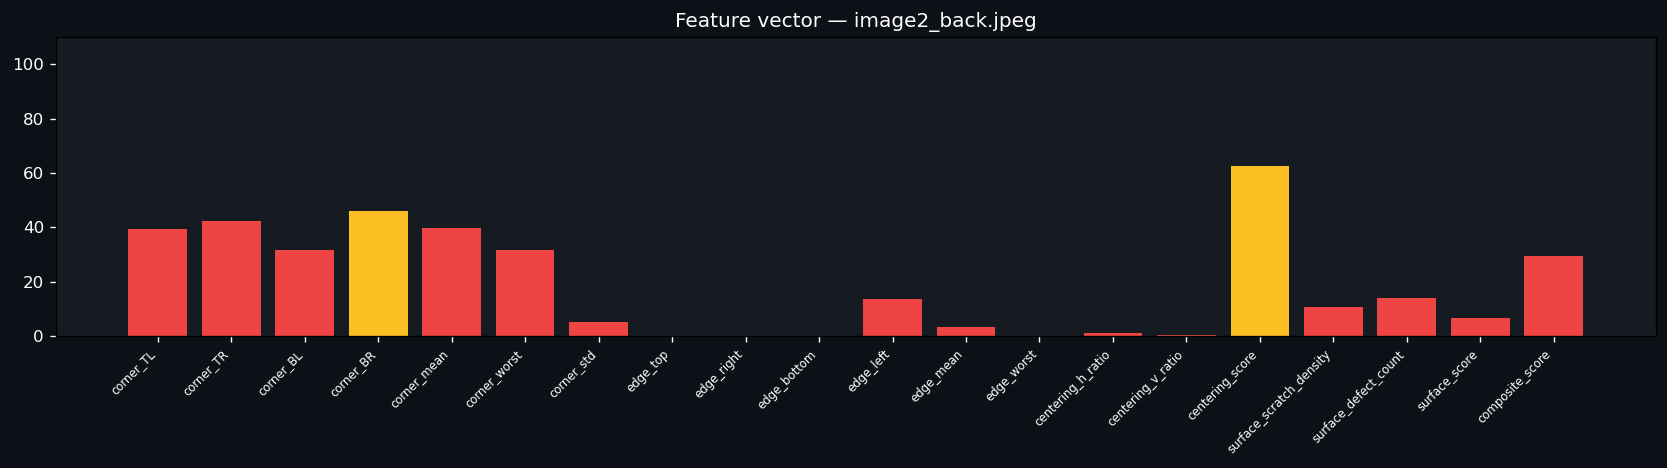

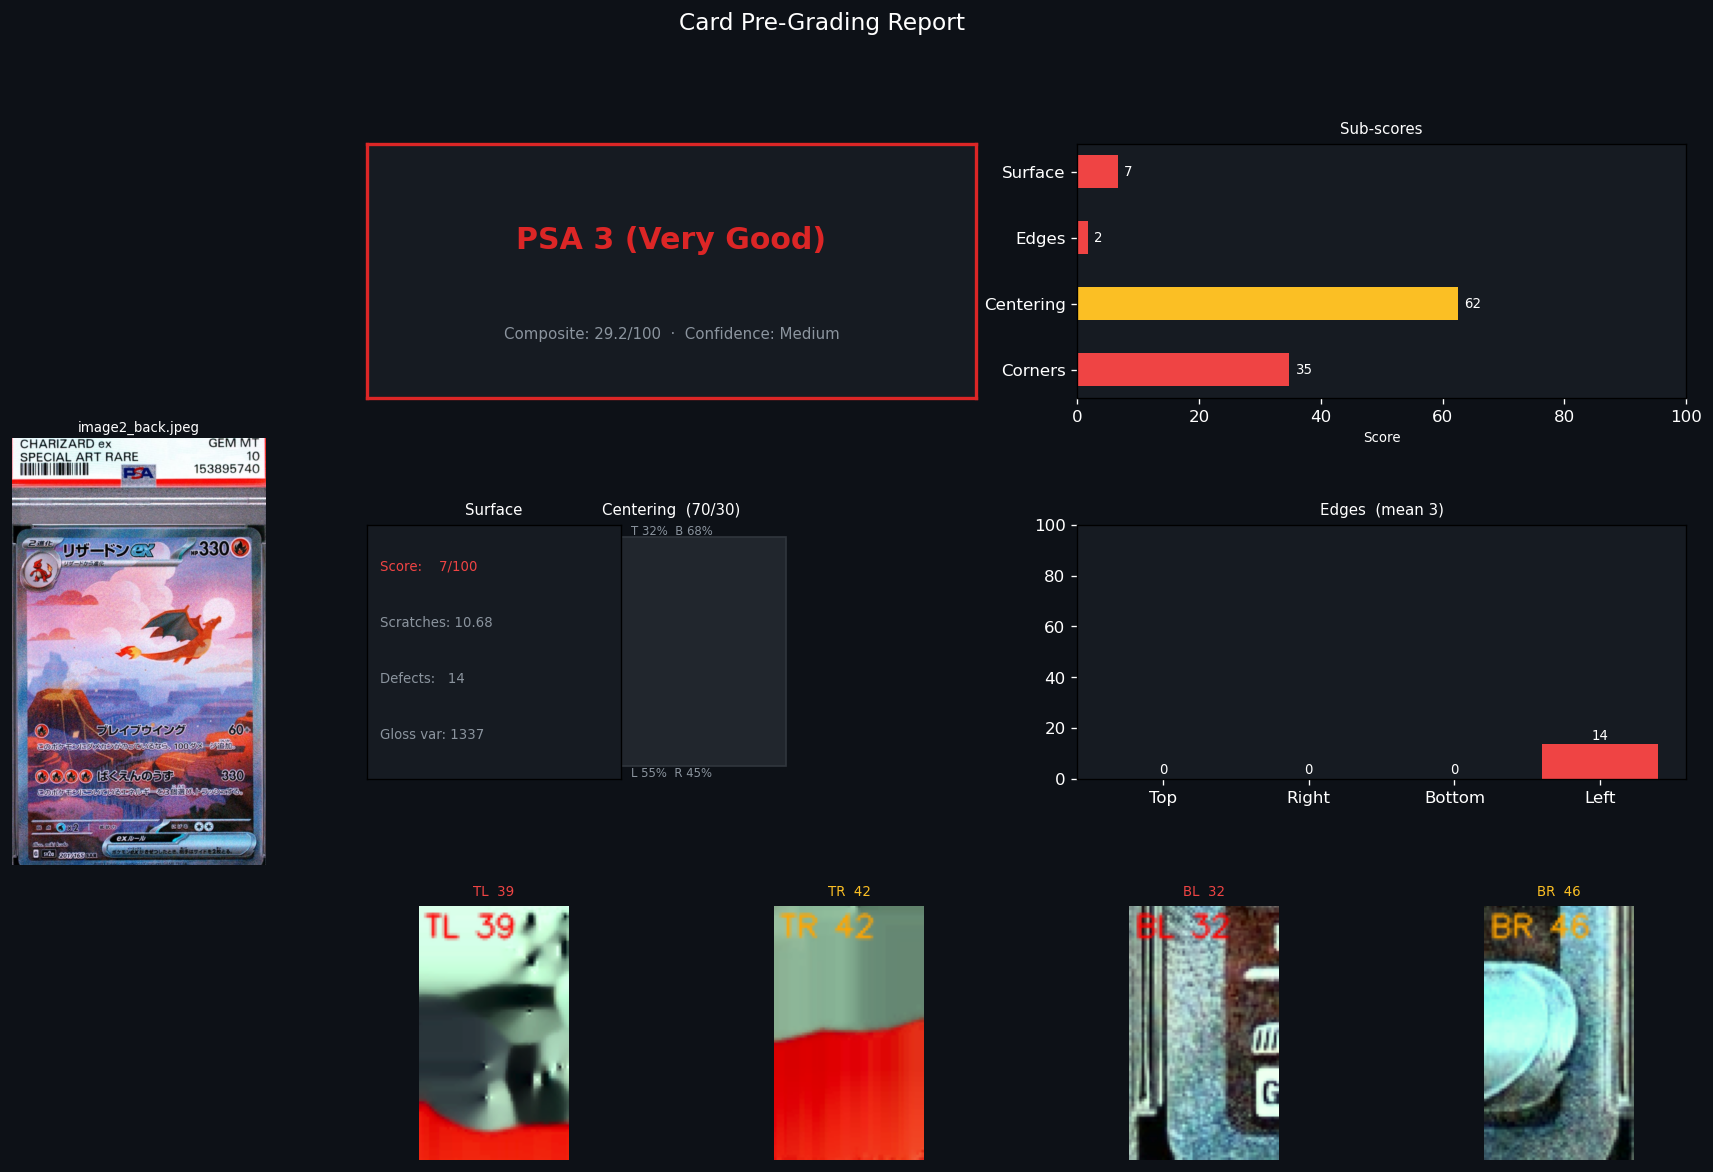

In [27]:
# ── SET YOUR IMAGE PATH ───────────────────────────────────────────
IMAGE_PATH  = 'cards/image2_back.jpeg'   # ← change as needed
CARD_TYPE   = 'pokemon'            # pokemon | sports | mtg | yugioh
# ─────────────────────────────────────────────────────────────────

# 1. Quality check
qr = check_image_quality(IMAGE_PATH)
print_quality_report(qr)

# 2. Centering profile visualization
try:
    show_centering_profiles(IMAGE_PATH)
except Exception as e:
    print(f'Centering viz error: {e}')

# 3. Normalization comparison
try:
    show_normalization_comparison(IMAGE_PATH)
except Exception as e:
    print(f'Normalization viz error: {e}')

# 4. Full improved grade
report, qr = grade_card_v2(IMAGE_PATH, yolo_model=yolo_model, card_type=CARD_TYPE)

print(f'\n{"─"*52}')
print(f'  {report.psa_label}')
print(f'  Composite : {report.composite:.1f} / 100')
print(f'  Confidence: {report.confidence}')
print(f'  Centering : {report.centering.grade}  (h={report.centering.h_ratio:.2f}  v={report.centering.v_ratio:.2f})')
print(f'  Corners   : mean {report.sub_scores["corners"]:.1f}  worst {report.corners.worst:.1f}')
print(f'  Edges     : mean {report.sub_scores["edges"]:.1f}   worst {report.edges.worst:.1f}')
print(f'  Surface   : {report.sub_scores["surface"]:.1f}')
print(f'  Detection : {"YOLO" if yolo_model else "contour"}')
print(f'  Calibrated: {calibration_model.trained}')
print(f'─────────────────────────────────────────────────────')

# 5. Feature vector plot
plot_feature_vector(report)

# 6. Standard visual dashboard
plot_report(report, IMAGE_PATH)

## 23. Saliency Maps — Visual Explanation

Two complementary views of *why* the model assigned a grade:

### A. CV Attribution Heatmap (always available)
Spatially overlays each sub-analyzer's score directly onto the card:
- **Corners** (10 % patches at each corner) — colored green→red by corner score
- **Edges** (5 % strips) — colored by edge score
- **Surface** (inner artwork region) — colored by surface score
- **Centering borders** — detected boundary lines drawn in amber

### B. Grad-CAM on ResNet-18 (requires PyTorch + a trained model)
Standard gradient-weighted class activation map showing which pixels
a CNN attended to. Useful once you have a trained deep model (see
Section 24 for the training pipeline inspired by `mint_condition`).

In [ ]:
def score_to_bgr(score: float) -> tuple:
    """Map 0-100 score to BGR color: red(0) → amber(50) → green(100)."""
    score = float(np.clip(score, 0, 100))
    if score >= 70:
        # green zone: interpolate green → bright green
        t = (score - 70) / 30.0
        r = int(0   * (1-t) + 0   * t)
        g = int(200 * (1-t) + 255 * t)
        b = int(50  * (1-t) + 50  * t)
    elif score >= 40:
        # amber zone: interpolate amber → green
        t = (score - 40) / 30.0
        r = int(0   * (1-t) + 0   * t)
        g = int(160 * (1-t) + 200 * t)
        b = int(200 * (1-t) + 50  * t)
    else:
        # red zone
        t = score / 40.0
        r = int(50  * (1-t) + 0   * t)
        g = int(50  * (1-t) + 160 * t)
        b = int(200 * (1-t) + 200 * t)
    return (b, g, r)


def build_cv_heatmap(card: np.ndarray, report: GradeReport,
                     alpha: float = 0.45) -> np.ndarray:
    """
    Overlay per-region scores as a semi-transparent color mask on the card.

    Regions
    -------
    - 4 corner patches  → colored by individual corner score
    - 4 edge strips     → colored by individual edge score
    - inner surface     → colored by surface score
    - centering lines   → amber lines showing detected border positions
    """
    h, w = card.shape[:2]
    overlay = card.copy().astype(np.float32)
    mask    = np.zeros((h, w, 3), dtype=np.float32)

    cp = int(h * 0.10)   # corner patch size (10 %)
    cw = int(w * 0.10)
    ep_h = max(4, int(h * 0.05))   # edge strip thickness
    ep_w = max(4, int(w * 0.05))

    # ── Corner regions ────────────────────────────────────────────
    corner_coords = [
        (slice(0, cp),    slice(0, cw)),     # TL
        (slice(0, cp),    slice(w-cw, w)),   # TR
        (slice(h-cp, h),  slice(0, cw)),     # BL
        (slice(h-cp, h),  slice(w-cw, w)),   # BR
    ]
    for (rs, cs), score in zip(corner_coords, report.corners.scores):
        color = np.array(score_to_bgr(score), dtype=np.float32)
        mask[rs, cs] = color

    # ── Edge strips (excluding corners) ──────────────────────────
    edge_regions = [
        (slice(0, ep_h),      slice(cw, w-cw)),   # top
        (slice(ep_h, h-ep_h), slice(w-ep_w, w)),  # right
        (slice(h-ep_h, h),    slice(cw, w-cw)),   # bottom
        (slice(ep_h, h-ep_h), slice(0, ep_w)),    # left
    ]
    for (rs, cs), score in zip(edge_regions, report.edges.scores):
        color = np.array(score_to_bgr(score), dtype=np.float32)
        mask[rs, cs] = color

    # ── Surface / artwork area ────────────────────────────────────
    surf_color = np.array(score_to_bgr(report.surface.score), dtype=np.float32)
    mask[ep_h:h-ep_h, ep_w:w-ep_w] = surf_color

    # ── Blend: overlay = card * (1-alpha) + mask * alpha ─────────
    blended = (card.astype(np.float32) * (1-alpha) +
               mask * alpha).clip(0, 255).astype(np.uint8)

    # ── Centering borders (amber lines) ──────────────────────────
    cen = report.centering
    top_y    = int(cen.top_pct    * h)
    bot_y    = int((1 - cen.bottom_pct) * h)
    left_x   = int(cen.left_pct  * w)
    right_x  = int((1 - cen.right_pct) * w)
    amber = (0, 165, 255)   # BGR amber
    lw = max(2, h // 200)
    cv2.line(blended, (0, top_y),   (w, top_y),   amber, lw)
    cv2.line(blended, (0, bot_y),   (w, bot_y),   amber, lw)
    cv2.line(blended, (left_x, 0),  (left_x, h),  amber, lw)
    cv2.line(blended, (right_x, 0), (right_x, h), amber, lw)

    # ── Score labels on each region ───────────────────────────────
    label_positions = [
        # corners
        (int(cw*0.15),   int(cp*0.7),   report.corners.scores[0], 'TL'),
        (int(w-cw*0.85), int(cp*0.7),   report.corners.scores[1], 'TR'),
        (int(cw*0.15),   int(h-cp*0.4), report.corners.scores[2], 'BL'),
        (int(w-cw*0.85), int(h-cp*0.4), report.corners.scores[3], 'BR'),
    ]
    for (x, y, sc, lbl) in label_positions:
        cv2.putText(blended, f'{lbl} {sc:.0f}',
                    (x, y), cv2.FONT_HERSHEY_SIMPLEX,
                    max(0.3, h/2000), (255, 255, 255), 1, cv2.LINE_AA)

    return blended


def plot_saliency_cv(image_path: str, report: GradeReport = None):
    """
    Full saliency dashboard: original card, heatmap overlay, and score legend.
    Pass a pre-computed report or let the function grade the card first.
    """
    _, card, _ = extract_card(image_path)

    if report is None:
        report, _ = grade_card_v2(image_path, normalize=True,
                                   skip_quality_check=True)

    heatmap = build_cv_heatmap(card, report)

    # ── Score legend bar ─────────────────────────────────────────
    bar_h, bar_w = 30, card.shape[1]
    legend = np.zeros((bar_h, bar_w, 3), dtype=np.uint8)
    for x in range(bar_w):
        score = x / bar_w * 100
        legend[:, x] = score_to_bgr(score)[::-1]   # BGR→RGB handled by imshow
    for score, label in [(0, '0'), (50, '50'), (70, '70'), (100, '100')]:
        x = int(score / 100 * bar_w)
        cv2.putText(legend, label, (max(0, x-8), 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 8),
                              gridspec_kw={'width_ratios': [1, 1, 0.55]})
    fig.patch.set_facecolor('#0d1117')

    # Original
    axes[0].imshow(cv2.cvtColor(card, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original', color='white', fontsize=11)
    axes[0].axis('off')

    # Heatmap
    axes[1].imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
    axes[1].set_title(
        f'CV Attribution Heatmap  ·  {report.psa_label}', color='white', fontsize=11)
    axes[1].axis('off')

    # Score card panel
    ax = axes[2]
    ax.set_facecolor('#161b22')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('Region Scores', color='white', fontsize=11)

    rows = [
        ('Corner TL',  report.corners.scores[0]),
        ('Corner TR',  report.corners.scores[1]),
        ('Corner BL',  report.corners.scores[2]),
        ('Corner BR',  report.corners.scores[3]),
        ('Edge Top',   report.edges.scores[0] if len(report.edges.scores)>0 else 0),
        ('Edge Right', report.edges.scores[1] if len(report.edges.scores)>1 else 0),
        ('Edge Bot',   report.edges.scores[2] if len(report.edges.scores)>2 else 0),
        ('Edge Left',  report.edges.scores[3] if len(report.edges.scores)>3 else 0),
        ('Surface',    report.surface.score),
        ('Centering',  report.centering.score),
        ('─'*18, None),
        ('Composite',  report.composite),
    ]

    y = 0.97
    for label, score in rows:
        if score is None:
            ax.axhline(y + 0.01, color='#30363d', lw=0.8, xmin=0.02, xmax=0.98)
            y -= 0.045
            continue
        r_norm, g_norm, b_norm = [c/255 for c in score_to_bgr(score)[::-1]]
        clr = (r_norm, g_norm, b_norm)
        # Mini bar
        ax.barh(y, score/100 * 0.55, height=0.055, left=0.43,
                color=clr, alpha=0.85)
        ax.text(0.02, y, label,    color='#8b949e', fontsize=8, va='center')
        ax.text(0.38, y, f'{score:.0f}', color=clr,   fontsize=8, va='center', ha='right')
        y -= 0.075

    plt.tight_layout()
    plt.show()


print('✅ CV attribution heatmap ready — call plot_saliency_cv(IMAGE_PATH, report)')

### B. Grad-CAM on a Trained ResNet-18

Requires **PyTorch** and a trained model checkpoint. Once you have a model
(trained via Section 24's pipeline), this shows gradient-weighted class
activation maps on the card image — the same technique used by `mint_condition`.

In [ ]:
def gradcam_heatmap(model, image_path: str, target_layer_name: str = 'layer4',
                    target_class: int = None) -> np.ndarray:
    """
    Compute Grad-CAM heatmap for a ResNet-style model.

    Parameters
    ----------
    model            : trained torchvision ResNet (any variant)
    image_path       : path to card photo
    target_layer_name: conv layer to hook (default 'layer4' — deepest ResNet block)
    target_class     : class index to explain (None = argmax of prediction)

    Returns
    -------
    heatmap: BGR uint8 image, same size as input card
    """
    try:
        import torch
        import torch.nn.functional as F
        from torchvision import transforms
    except ImportError:
        print('PyTorch not installed — run: pip install torch torchvision')
        return None

    _, card, _ = extract_card(image_path)
    card_rgb   = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)
    h, w       = card.shape[:2]

    # ── Preprocess ────────────────────────────────────────────────
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((255, 255)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    inp = preprocess(card_rgb).unsqueeze(0)   # (1, 3, 255, 255)

    # ── Hook to capture activations and gradients ─────────────────
    activations, gradients = [], []

    def fwd_hook(module, input, output):
        activations.append(output.detach())

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    target_layer = dict(model.named_modules())[target_layer_name]
    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    # ── Forward pass ──────────────────────────────────────────────
    model.eval()
    with torch.enable_grad():
        logits = model(inp)
        if target_class is None:
            target_class = int(logits.argmax(dim=1))
        score = logits[0, target_class]
        model.zero_grad()
        score.backward()

    h1.remove(); h2.remove()

    # ── Grad-CAM weights: global average pool of gradients ────────
    grads  = gradients[0].squeeze(0)   # (C, H_feat, W_feat)
    acts   = activations[0].squeeze(0) # (C, H_feat, W_feat)
    weights = grads.mean(dim=(1, 2))   # (C,)

    cam = (weights[:, None, None] * acts).sum(dim=0)
    cam = F.relu(cam)

    # Normalize and resize to card dimensions
    cam = cam.numpy()
    cam -= cam.min()
    if cam.max() > 0:
        cam /= cam.max()
    cam_resized = cv2.resize(cam, (w, h))

    # Convert to BGR heatmap
    heatmap_uint8 = (cam_resized * 255).astype(np.uint8)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    # Overlay on original card
    overlay = cv2.addWeighted(card, 0.55, heatmap_color, 0.45, 0)

    return overlay, cam_resized, target_class


def plot_gradcam(model, image_path: str, class_names: list = None):
    """
    Show Grad-CAM overlay for the predicted class alongside the original card.
    """
    result = gradcam_heatmap(model, image_path)
    if result is None:
        return
    overlay, cam, pred_class = result
    _, card, _ = extract_card(image_path)

    label = class_names[pred_class] if class_names else f'class {pred_class}'

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.patch.set_facecolor('#0d1117')

    axes[0].imshow(cv2.cvtColor(card, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original', color='white')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Grad-CAM  →  Predicted: {label}', color='white')
    axes[1].axis('off')

    axes[2].imshow(cam, cmap='jet')
    axes[2].set_title('Raw Activation Map', color='white')
    axes[2].axis('off')
    axes[2].figure.colorbar(
        plt.cm.ScalarMappable(cmap='jet'),
        ax=axes[2], fraction=0.046, pad=0.04
    ).ax.yaxis.set_tick_params(color='white')

    plt.suptitle('Grad-CAM Saliency — which card regions drove the prediction',
                 color='white', fontsize=12)
    plt.tight_layout()
    plt.show()


# ── Usage example (requires trained model) ────────────────────────
print('✅ Grad-CAM ready')
print()
print('Usage (once you have a trained ResNet):')
print('  from torchvision.models import resnet18')
print('  model = resnet18(num_classes=5)')
print('  model.load_state_dict(torch.load("resnet18_grader.pt"))')
print('  plot_gradcam(model, IMAGE_PATH, class_names=["Poor","VG","EX","NM","Mint"])')

## 24. ResNet-18 Training Pipeline

Mirrors the `mint_condition` approach: collect eBay images labeled by PSA grade
(parsed from listing titles), fine-tune ResNet-18, evaluate against human baseline.

Key insight from `mint_condition`: training **from scratch** on card-specific
low-level features (scratches, print lines, rounded corners) outperformed
fine-tuning from ImageNet weights. We use **pretrained + fine-tuned** here as a
starting point — experiment with `freeze_backbone=False` for scratch training.

In [ ]:
def build_resnet_grader(num_classes: int = 5, pretrained: bool = True,
                        freeze_backbone: bool = False):
    """
    Build a ResNet-18 for card grade classification.

    num_classes: 5 (Poor/VG/EX/NM/Mint buckets, mirrors mint_condition)
                 or 10 (individual PSA grades 1-10)
    freeze_backbone: True = only train the final FC layer (fast, less data needed)
                     False = train all layers (needs more data, potentially better)
    """
    try:
        import torch
        import torch.nn as nn
        from torchvision import models
    except ImportError:
        print('Install PyTorch: pip install torch torchvision')
        return None

    weights = 'IMAGENET1K_V1' if pretrained else None
    model   = models.resnet18(weights=weights)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


# PSA 1-10 → 5-bucket mapping (matches mint_condition's framing)
PSA_TO_BUCKET = {1: 0, 2: 0,          # Poor
                 3: 1, 4: 1,          # Very Good
                 5: 2, 6: 2,          # Excellent
                 7: 3, 8: 3,          # Near Mint
                 9: 4, 10: 4}         # Mint
BUCKET_NAMES  = ['Poor', 'Very Good', 'Excellent', 'Near Mint', 'Mint']


def train_resnet_grader(image_dir: str,
                        model_out:  str  = 'resnet18_grader.pt',
                        num_classes: int = 5,
                        epochs:      int = 10,
                        batch_size:  int = 32,
                        lr:          float = 1e-4):
    """
    Fine-tune ResNet-18 on a folder of labeled card images.

    Expected folder structure:
        image_dir/
            psa_1/   (or bucket_0/ if using 5-class)
            psa_2/
            ...
            psa_10/

    Or flat with filenames like: grade_9_page_3_id_42.jpg
    (grade parsed from filename — matches mint_condition naming convention)
    """
    try:
        import torch
        import torch.nn as nn
        from torch.utils.data import Dataset, DataLoader, random_split
        from torchvision import transforms
        from sklearn.metrics import f1_score
        from scipy.stats import spearmanr
    except ImportError:
        print('Install deps: pip install torch torchvision scikit-learn scipy')
        return

    from pathlib import Path

    # ── Dataset ────────────────────────────────────────────────────
    class CardDataset(Dataset):
        def __init__(self, image_dir, transform, num_classes):
            self.samples   = []
            self.transform = transform
            img_dir = Path(image_dir)

            # Support two layouts:
            # 1. Subdirs named psa_9/, grade_9/, 9/
            # 2. Flat files named grade_9_*.jpg
            for path in sorted(img_dir.rglob('*.jpg')) + sorted(img_dir.rglob('*.jpeg')):
                grade = None
                # Try parent folder name
                try:
                    grade = int(''.join(filter(str.isdigit, path.parent.name)))
                except ValueError:
                    pass
                # Try filename prefix
                if grade is None:
                    import re
                    m = re.search(r'grade_(\d+)', path.stem)
                    if m:
                        grade = int(m.group(1))
                if grade and 1 <= grade <= 10:
                    label = PSA_TO_BUCKET[grade] if num_classes == 5 else grade - 1
                    self.samples.append((str(path), label))

        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            path, label = self.samples[idx]
            img = cv2.imread(path)
            if img is None:
                img = np.zeros((255, 255, 3), dtype=np.uint8)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            return self.transform(img), label

    train_tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((255, 255)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomAffine(degrees=15, shear=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((255, 255)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    full_ds = CardDataset(image_dir, train_tf, num_classes)
    if len(full_ds) == 0:
        print(f'No images found in {image_dir}. Check folder layout.'); return

    n_val   = max(1, int(len(full_ds) * 0.10))
    n_train = len(full_ds) - n_val
    train_ds, val_ds = random_split(full_ds, [n_train, n_val])
    val_ds.dataset   = CardDataset(image_dir, val_tf, num_classes)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    # ── Model & optimizer ─────────────────────────────────────────
    device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
    model  = build_resnet_grader(num_classes=num_classes, pretrained=True,
                                  freeze_backbone=False)
    model  = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = __import__('torch').optim.Adam(model.parameters(), lr=lr)
    scheduler = __import__('torch').optim.lr_scheduler.StepLR(
        optimizer, step_size=4, gamma=0.5)

    print(f'Training ResNet-18  |  {len(full_ds)} images  |  '
          f'{num_classes} classes  |  device={device}')
    print(f'{'Epoch':>6} {'Train Acc':>10} {'Val Acc':>9} {'Val F1':>8} '
          f'{'Spearman':>10}')

    import torch
    history = []
    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────────
        model.train()
        correct = total = 0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total   += len(labels)
        train_acc = correct / max(total, 1)

        # ── Validate ──────────────────────────────────────────────
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs = imgs.to(device)
                preds = model(imgs).argmax(1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.numpy())

        val_acc = sum(p==l for p,l in zip(all_preds, all_labels)) / max(len(all_labels), 1)
        val_f1  = f1_score(all_labels, all_preds, average='micro', zero_division=0)
        rho, _  = spearmanr(all_labels, all_preds)

        print(f'{epoch:>6}   {train_acc:>9.1%}   {val_acc:>8.1%}   '
              f'{val_f1:>7.3f}   {rho:>9.3f}')
        history.append({'epoch': epoch, 'train_acc': train_acc,
                        'val_acc': val_acc, 'f1': val_f1, 'spearman': rho})
        scheduler.step()

    # ── Save ──────────────────────────────────────────────────────
    torch.save(model.state_dict(), model_out)
    print(f'\n✅ Model saved → {model_out}')
    print(f'   Best val acc : {max(r["val_acc"] for r in history):.1%}')
    print(f'   Best Spearman: {max(r["spearman"] for r in history):.3f}')
    print(f'   Human baseline (mint_condition): 31.1%')
    return model, history


print('✅ ResNet-18 training pipeline ready')
print()
print('Usage:')
print('  model, history = train_resnet_grader(')
print('      image_dir  = "cards/",   # folder with psa_1/ ... psa_10/ subfolders')
print('      model_out  = "resnet18_grader.pt",')
print('      num_classes= 5,           # 5 buckets (Poor/VG/EX/NM/Mint)')
print('      epochs     = 10,')
print('  )')

## 25. Demo — Saliency Map on a Real Card

In [ ]:
# ── SET IMAGE PATH ────────────────────────────────────────────────
IMAGE_PATH = 'image0_back.jpeg'   # ← change as needed
# ─────────────────────────────────────────────────────────────────

# Grade the card first (reuse if already done in Section 22)
report, _ = grade_card_v2(IMAGE_PATH, yolo_model=yolo_model,
                           card_type='pokemon', skip_quality_check=True)

# CV Attribution Heatmap — always works, no PyTorch required
plot_saliency_cv(IMAGE_PATH, report)